# 04. Business Metrics — 국제선 수요·운항 안정성

### 단계 연결

- 이전 작업(03): 국제선 수요와 출발 로그를 탐색하고 국제선 범위, 두 가지 지연률, 분모, 자정 보정, 취소·회항 처리 방향을 확정했다.
- 이번 작업(04): 확정 규칙을 재사용 가능한 비즈니스 지표로 구현하고, 수요와 운항 안정성을 표와 차트로 비교한다.

## 분석 개요

전국 공항의 국제선 수요와 인천·김포 출발 국제선 여객편의 운항 안정성을 재사용 가능한 지표로 정리한다. 수요 지표는 전국 집계이고 운항 안정성 지표는 인천·김포 출발 로그이므로, 두 범위의 값은 서로 같은 모집단의 합계가 아니다.

- 분석 대상은 `is_passenger = TRUE`이면서 `is_international = TRUE`인 운항 로그이며, 국제선 판별 미확정 행은 제외한다.
- 상태 지연률(`status_delay_rate`)은 상태가 `출발` 또는 `지연`인 편을 분모로 하고, 상태가 `지연`인 편을 분자로 한다.
- 15분 시간 지연률(`time_delay_15_rate`)은 상태가 `출발` 또는 `지연`이고 시간 계산이 가능한 편을 분모로 한다. 보정된 실제-계획 출발시간 차이가 15분 이상인 편이 분자다.
- 실제-계획 출발시간 차이(`raw_gap_minutes`)가 -720분 이하일 때만 1,440분을 더한다.
- 취소율과 회항률은 각각 취소·회항 편 수를 분석 대상 국제선 여객편 로그 전체로 나눈다.
- 평균 실제-계획 출발시간 차이는 시간 지연률 분모 편 전체를 대상으로 한다. 평균·중앙 지연시간은 15분 이상 시간 지연편만 대상으로 한다.
- 지연사유의 `회항`은 원인이 아닌 운항 결과로 보아 지연사유 집계에서 제외한다.

## 04 분석 브리프

04는 03에서 확정한 지표를 사용해 **핵심 시장과 성장 후보를 구분하고, 목적지별 수요 시점과 운항 리스크를 항공사 추천에 활용할 수 있는 근거로 정리하는 문제**를 담당한다.

### 분석 흐름

| 단계 | 한 줄 주제 | 이 단계에서 답할 질문 |
|---|---|---|
| §1 | **수요 규모와 집중도** | 핵심 공항·국가·목적지는 어디이며 비중은 어떻게 변하는가? |
| §2 | **계절별 목적지 분석** | 목적지별 월별 상대 수요 패턴은 어떻게 다른가? |
| §3 | **성장 목적지 분석** | 최근 성장 목적지 중 일부에서 여객·운항 증가율의 차이가 나타나는가? |
| §3-1 | **대륙별 방문 도시** | 대륙별 인기 도시와 떠오르는 도시는 어디인가? |
| §4 | **운항 안정성 분석** | 서로 다른 지연률과 취소·회항을 어떤 기준으로 구분해야 하는가? |
| §5 | **수요와 운항 안정성 결합** | 인기·성장성과 운항 안정성은 같은 방향으로 움직이며, 누적 순위만으로 후보를 충분히 찾을 수 있는가? |

### 분석 가설과 확인 기준

| 구분 | 검토 내용 | 관찰 데이터 확인 기준 | 연결 섹션 |
|---|---|---|---|
| 가설 1 · 핵심 시장 집중 | 여객이 많은 공항·국가·목적지·노선은 전체 수요에서 차지하는 비중이 크고, 그 비중은 해마다 달라질 것이다. | 3개년 누적 여객 순위와 연도별 개별 비중 변화를 함께 비교한다. | §1 |
| 가설 2 · 목적지별 계절성 | 주요 목적지는 월마다 상대적으로 수요가 높은 시기가 서로 다를 것이다. | 3개 연도 모두 관측된 목적지의 월별 평균 계절 지수 차이를 비교한다. | §2 |
| 가설 3 · 수요·운항 증가의 비대칭 | 최근 여객이 늘어난 목적지 중에는 여객 증가율과 운항편 증가율이 서로 다른 곳이 있을 것이다. | 2024년 대비 2025년 여객·운항 증가 수와 증가율을 목적지별로 비교한다. | §3 |
| 보조 분석 질문 · 대륙별 방문 도시 | 대륙별로 인기 있는 방문 도시와 떠오르는 도시는 어디인가? | 목적지-지역 매핑을 적용한 뒤 대륙 안에서 누적 수요와 최근 여객 증가 수 Top 10을 각각 비교한다. | §3-1 |
| 보조 분석 질문 · 운항 지표 | 상태 지연률과 15분 시간 지연률은 실제로 얼마나 다르며 하나의 지표로 요약할 수 있는가? | 동일한 월·공항·목적지에서 두 지연률과 취소·회항을 분리해 확인한다. | §4 |
| 가설 4 · 수요와 운항 안정성 | 여객이 많거나 증가한 목적지·항공사라고 해서 지연률도 반드시 높거나 증가하지는 않을 것이다. | 상위 항공사·목적지의 연간 여객과 두 지연률이 항상 같은 방향으로 움직이는지 비교한다. | §5 |
| ↳ 후속 분석 질문 · 후보 범위 | 누적 수요 상위만 사용하면 2024년 대비 2025년 여객 증가 수 상위 목적지를 얼마나 놓치는가? | 누적 상위·2025년 수요 상위·2024년 대비 2025년 여객 증가 수 상위 10개의 합집합과 추가 후보를 확인한다. | §5.1 |

가설 1-4는 03 EDA와 프로젝트 문제 정의에서 도출할 수 있는 예상 방향으로 재정리했다. 분석 완료 후 확인된 세부 수치를 가설 문장에 넣지 않았으며, 사전등록된 추론 검정으로 보지 않는다. 따라서 채택·입증보다 관찰 결과가 예상 방향과 일치했는지, 그 규모가 의사결정에 어떤 의미가 있는지를 중심으로 해석한다. 보조·후속 분석 질문은 방향을 판정하기보다 지표 해석과 후보 범위를 구체화한다.


## 분석 준비 · 핵심 비즈니스 뷰 생성

9개 핵심 뷰를 생성·갱신한다. `v_business_flight_base`는 운항 식별·필수 원문값·확정 규칙 컬럼만 전달한다. `v_metric_delay_reason_monthly`는 월·공항·항공사·목적지·지연사유 단위의 건수를 보존하므로, 대시보드 필터를 적용한 뒤 지연사유 비중을 다시 계산할 수 있다.


In [1]:
from pathlib import Path
import os
import re


import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from IPython.display import display

PLOTLY_TEMPLATE = 'plotly_white'

def _format_chart_period(value) -> str:
    text_value = str(value).strip().removesuffix('.0')
    if re.fullmatch(r'\d{6}', text_value):
        return f'{text_value[:4]}-{text_value[4:6]}'
    if re.fullmatch(r'\d{4}', text_value):
        return text_value
    try:
        return pd.to_datetime(value).strftime('%Y-%m')
    except (TypeError, ValueError):
        return text_value

def chart_title(title: str, periods, note: str | None = None) -> str:
    period_values = pd.Series(list(periods)).dropna().map(_format_chart_period)
    if period_values.empty:
        return title
    start_period = period_values.min()
    end_period = period_values.max()
    period_text = start_period if start_period == end_period else f'{start_period} ~ {end_period}'
    detail_text = f'데이터 범위: {period_text}'
    if note:
        detail_text = f'{detail_text} · {note}'
    return f'{title}<br><sup>{detail_text}</sup>'
pd.set_option('display.max_columns', None)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

load_dotenv(ROOT / '.env')
SQL_FILE = ROOT / 'sql' / '04_business_metrics.sql'

db_config = {
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT', '3306')),
    'database': os.getenv('DB_NAME'),
    'username': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
}
missing = [key for key in ['host', 'database', 'username', 'password'] if not db_config[key]]
if missing:
    raise ValueError(f'.env의 DB 설정이 비어 있음: {missing}')

engine = create_engine(URL.create('mysql+pymysql', **db_config), pool_pre_ping=True, future=True)

def load_named_queries(path: Path) -> dict[str, str]:
    sql_text = path.read_text(encoding='utf-8')
    matches = list(re.finditer(r'^-- name: ([a-z0-9_]+)\s*$', sql_text, flags=re.MULTILINE))
    return {
        match.group(1): sql_text[match.end(): matches[index + 1].start() if index + 1 < len(matches) else len(sql_text)].strip().rstrip(';')
        for index, match in enumerate(matches)
    }

SQL = load_named_queries(SQL_FILE)

COLUMN_LABELS = {
    'view_name': '뷰 이름',
    'first_period_ym': '시작 연월',
    'last_period_ym': '종료 연월',
    'rows_count': '행 수',
    'period_ym': '연월',
    'operating_month': '운항 연월',
    'operating_year': '연도',
    'airport_name_raw': '출발공항 원문',
    'airport_std': '출발공항 표준값',
    'region_raw': '지역 원문',
    'country_raw': '국가 원문',
    'airline_std': '항공사 표준값',
    'annual_passenger_yoy_rate': '여객 전년 대비 증감률',
    'total_rank': '3개년 누적 순위',
    'total_period_passengers': '3개년 누적 여객 수',
    'total_period_scheduled_flight_rows': '3개년 누적 운항 로그 수',
    'cumulative_rank': '3개년 누적 순위',
    'latest_year_rank': '최신 연도 수요 순위',
    'growth_rank': '최근 여객 증가 순위',
    'latest_year_passenger_growth': '최신 연도 여객 증가 수',
    'selection_reason': '선정 사유',
    'previous_annual_passengers': '전년 여객 수',
    'previous_annual_operations': '전년 운항편 수',
    'annual_operation_yoy_rate': '운항 전년 대비 증감률',
    'latest_year_scheduled_flight_rows': '최신 연도 분석 대상 운항 로그 수',
    'previous_year_scheduled_flight_rows': '비교 연도 분석 대상 운항 로그 수',
    'previous_year_status_delay_rate': '비교 연도 상태 지연률',
    'status_delay_rate_change_pp': '상태 지연률 전년 대비 변화(%p)',
    'previous_year_time_delay_15_rate': '비교 연도 15분 시간 지연률',
    'time_delay_15_rate_change_pp': '15분 시간 지연률 전년 대비 변화(%p)',
    'origin_airport_std': '출발공항 표준값',
    'destination_canonical_std': '목적지 대표 표준값',
    'passengers': '여객 수',
    'operations': '운항편 수',
    'passenger_share': '여객 비중',
    'passengers_per_operation': '편당 여객 수',
    'previous_year_passengers': '전년 동월 여객 수',
    'passenger_yoy_rate': '여객 전년 동월 대비 증감률',
    'previous_year_operations': '전년 동월 운항편 수',
    'operation_yoy_rate': '운항 전년 동월 대비 증감률',
    'scheduled_flight_rows': '분석 대상 운항 로그 수',
    'status_operated_rows': '상태 지연률 분모 편 수',
    'status_delayed_rows': '상태 지연 편 수',
    'status_delay_rate': '상태 지연률',
    'time_delay_denominator_rows': '15분 시간 지연률 분모 편 수',
    'time_delayed_15_rows': '15분 이상 시간 지연 편 수',
    'time_delay_15_rate': '15분 시간 지연률',
    'cancelled_rows': '취소 편 수',
    'cancellation_rate': '취소율',
    'diverted_rows': '회항 편 수',
    'diversion_rate': '회항률',
    'status_unknown_rows': '상태 미상 편 수',
    'midnight_adjusted_rows': '자정 보정 편 수',
    'avg_departure_gap_minutes': '평균 실제-계획 출발시간 차이(분)',
    'avg_delay_minutes': '15분 시간 지연편 평균 지연시간(분)',
    'median_delay_minutes': '15분 시간 지연편 중앙 지연시간(분)',
    'delay_reason_category': '지연사유 분류',
    'delayed_flight_rows': '지연 편 수',
    'delay_reason_share': '지연사유 비중',
    'calendar_month': '월',
    'observed_years': '관측 연도 수',
    'avg_passengers': '평균 여객 수',
    'min_passengers': '최소 여객 수',
    'max_passengers': '최대 여객 수',
    'avg_passenger_seasonal_index': '평균 여객 계절 지수',
    'avg_operations': '평균 운항편 수',
    'demand_rank': '수요 순위',
    'latest_year': '최신 연도',
    'previous_year': '비교 연도',
    'latest_year_observed_months': '최신 연도 관측 월 수',
    'previous_year_observed_months': '비교 연도 관측 월 수',
    'latest_year_passengers': '최신 연도 여객 수',
    'comparison_year_passengers': '비교 연도 여객 수',
    'latest_year_operations': '최신 연도 운항편 수',
    'comparison_year_operations': '비교 연도 운항편 수',
    'passenger_growth': '여객 증가 수',
    'passenger_growth_rate': '여객 증가율',
    'operation_growth': '운항 증가 수',
    'operation_growth_rate': '운항 증가율',
    'metric_name': '지표 단위',
    'checked_months': '검증 월 수',
    'passenger_absolute_difference': '여객 절대 차이 합',
    'passenger_max_month_difference': '여객 월 최대 차이',
    'operation_absolute_difference': '운항 절대 차이 합',
    'operation_max_month_difference': '운항 월 최대 차이',
    'operation_difference_month_count': '운항 차이 발생 월 수',
    'operation_difference_periods': '운항 차이 발생 연월',
    'scheduled_row_difference': '분석 대상 운항 로그 수 차이',
    'status_operated_difference': '상태 지연률 분모 편 수 차이',
    'status_delayed_difference': '상태 지연 편 수 차이',
    'time_delay_denominator_difference': '15분 시간 지연률 분모 편 수 차이',
    'time_delayed_15_difference': '15분 이상 시간 지연 편 수 차이',
    'cancelled_difference': '취소 편 수 차이',
    'diverted_difference': '회항 편 수 차이',
    'status_unknown_difference': '상태 미상 편 수 차이',
}

def query(name: str) -> pd.DataFrame:
    result = pd.read_sql(text(SQL[name]), engine)
    return result.rename(columns=COLUMN_LABELS)

def execute_ddl(name: str) -> None:
    with engine.begin() as connection:
        connection.execute(text(SQL[name]))

with engine.connect() as connection:
    connection.execute(text('SELECT 1'))

print(f"Connected to MySQL database: {db_config['database']}")


Connected to MySQL database: korea_outbound_travel


In [2]:
DDL_NAMES = [
    'create_v_business_flight_base',
    'create_v_metric_demand_country_monthly',
    'create_v_metric_demand_destination_monthly',
    'create_v_metric_demand_route_monthly',
    'create_v_metric_operation_monthly',
    'create_v_metric_operation_airport_monthly',
    'create_v_metric_operation_airline_monthly',
    'create_v_metric_operation_destination_monthly',
    'create_v_metric_delay_reason_monthly',
]
for ddl_name in DDL_NAMES:
    execute_ddl(ddl_name)

display(pd.DataFrame({
    '실행 순서': range(1, len(DDL_NAMES) + 1),
    'SQL 블록': DDL_NAMES,
}))


,실행 순서,SQL 블록
0,1,create_v_business_flight_base
1,2,create_v_metric_demand_country_monthly
2,3,create_v_metric_demand_destination_monthly
3,4,create_v_metric_demand_route_monthly
4,5,create_v_metric_operation_monthly
5,6,create_v_metric_operation_airport_monthly
6,7,create_v_metric_operation_airline_monthly
7,8,create_v_metric_operation_destination_monthly
8,9,create_v_metric_delay_reason_monthly


## 분석 준비 · 규칙 적용 및 정합성 검증

확정 규칙의 적용 건수, 핵심 뷰 범위, 수요·운항 월별 합계 보존 여부만 확인한다.


In [3]:
# 공항별 확정 규칙 적용 결과를 확인한다.
display(query('business_rule_profile'))


,출발공항 원문,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,상태 지연률,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,15분 시간 지연률,자정 보정 편 수,취소 편 수,회항 편 수,상태 미상 편 수
0,김포,30899,30709.0,2232.0,0.0727,30604.0,15971.0,0.5219,0.0,27.0,8.0,155.0
1,인천,504543,501202.0,153285.0,0.3058,499530.0,426561.0,0.8539,2.0,693.0,81.0,2567.0


In [4]:
# 유지하는 9개 핵심 뷰의 기간과 행 수를 확인한다.
display(query('business_view_coverage'))


,뷰 이름,시작 연월,종료 연월,행 수
0,v_business_flight_base,202301,202512,535442
1,v_metric_delay_reason_monthly,202301,202512,39708
2,v_metric_demand_country_monthly,202301,202512,2047
3,v_metric_demand_destination_monthly,202301,202512,6493
4,v_metric_demand_route_monthly,202301,202512,9632
5,v_metric_operation_airline_monthly,202301,202512,2857
6,v_metric_operation_airport_monthly,202301,202512,72
7,v_metric_operation_destination_monthly,202301,202512,5259
8,v_metric_operation_monthly,202301,202512,36


In [5]:
# 수요 차원별 월 합계를 원본 집계 뷰와 비교한다.
display(query('demand_metric_monthly_total_check'))


,지표 단위,검증 월 수,여객 절대 차이 합,여객 월 최대 차이,운항 절대 차이 합,운항 월 최대 차이,운항 차이 발생 월 수,운항 차이 발생 연월
0,airport,36,0.0,0.0,NaN,NaN,0.0,None
1,country,36,0.0,0.0,NaN,NaN,0.0,None
2,airline,36,0.0,0.0,1.0,1.0,1.0,202305
3,destination,36,0.0,0.0,0.0,0.0,0.0,None
4,route,36,0.0,0.0,0.0,0.0,0.0,None


In [6]:
# 공항 운항 지표 합계를 공통 운항 범위와 비교한다.
display(query('operation_metric_total_check'))


,출발공항 원문,분석 대상 운항 로그 수 차이,상태 지연률 분모 편 수 차이,상태 지연 편 수 차이,15분 시간 지연률 분모 편 수 차이,15분 이상 시간 지연 편 수 차이,취소 편 수 차이,회항 편 수 차이
0,김포,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,인천,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 정합성 확인 결과

국제선 여객편 로그는 김포 30,899건과 인천 504,543건으로 총 535,442건이며, 자정 보정은 인천 2건에만 적용됐다. 9개 핵심 뷰는 모두 2023년 1월부터 2025년 12월 범위를 포함한다. 수요 차원의 월별 여객 합계와 운항 지표 건수는 기준 뷰와 일치한다.

2023년 5월 운항편 합계는 항공사별 원본 집계가 16,782편, 노선별 원본 집계가 16,781편으로 1편 차이가 있다. 이는 04의 계산 과정에서 새로 발생한 차이가 아니라 입력 집계 뷰 사이에 이미 존재하는 차이이므로, 이후 두 집계의 운항편 수를 직접 비교할 때 주의한다.

---

## 1. 수요 규모와 집중도

전국 공항에서 출발한 국제선 집계 데이터를 월별로 확인하고, 공항·국가·목적지·노선은 3개년 누적 여객 순위에 따라 연도별로 비교한다.

**가설 1.** 여객이 많은 공항·국가·목적지·노선은 전체 수요에서 차지하는 비중이 크고, 그 비중은 해마다 달라질 것이다.

**분석 관점.** 상위 시장의 개별 비중과 순위를 확인하되, 이를 시장 전체의 집중도 지수로 해석하지 않는다. 누적 규모와 연도별 비중 변화를 함께 보며 핵심 시장의 구성이 달라지는지를 살핀다.

**가설 수립 근거 — [`03_eda.ipynb`](03_eda.ipynb) §2.** 인천공항의 국제선 출발 여객 비중이 79.11%였고 일본·중국·베트남의 수요가 크게 관찰됐다. 04에서는 상위 시장의 개별 비중이 연도별로 어떻게 달라지는지 공항·국가·목적지·노선 단위로 확대해 확인한다.

**확인 방법.** 2023-2025년 누적 여객으로 비교 대상을 고정하고, 연도별 여객 수·비중·순위 변화를 함께 제시한다.


In [7]:
monthly_demand_df = query('monthly_demand_metrics')
display(monthly_demand_df.head(5))


,연월,여객 수,운항편 수,편당 여객 수,전년 동월 여객 수,여객 전년 동월 대비 증감률,전년 동월 운항편 수,운항 전년 동월 대비 증감률
0,202301,2403433.0,13632.0,176.31,NaN,NaN,NaN,NaN
1,202302,2212589.0,12937.0,171.03,NaN,NaN,NaN,NaN
2,202303,2256529.0,14407.0,156.63,NaN,NaN,NaN,NaN
3,202304,2412373.0,15231.0,158.39,NaN,NaN,NaN,NaN
4,202305,2622755.0,16781.0,156.29,NaN,NaN,NaN,NaN


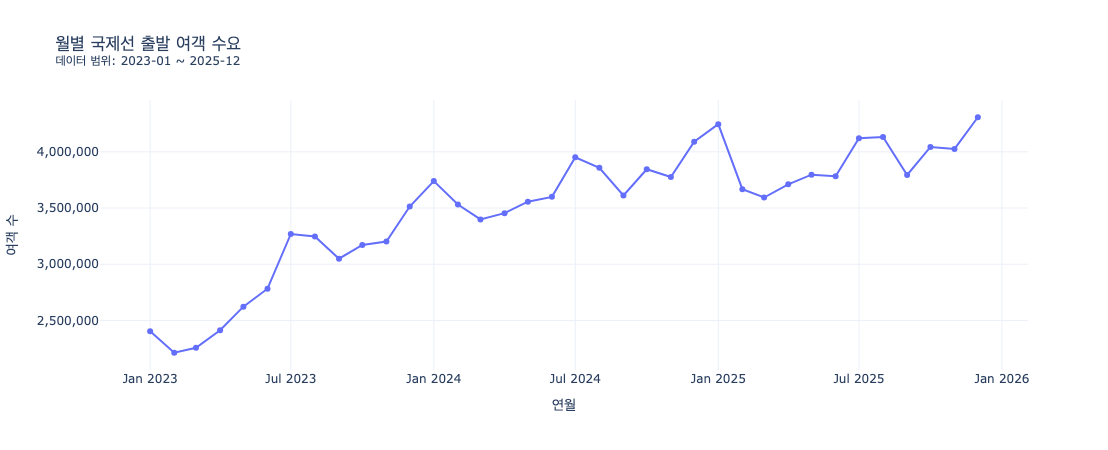

In [8]:
# 차트: 전체 기간의 월별 국제선 여객 수요 흐름을 확인한다.
demand_chart = monthly_demand_df.copy()
demand_chart['기준월'] = pd.to_datetime(demand_chart['연월'], format='%Y%m')

fig = px.line(
    demand_chart,
    x='기준월',
    y='여객 수',
    markers=True,
    title=chart_title('월별 국제선 출발 여객 수요', demand_chart['연월']),
    labels={'기준월': '연월', '여객 수': '여객 수'},
    template=PLOTLY_TEMPLATE,
)
fig.update_yaxes(tickformat=',')
fig.update_layout(height=450, showlegend=False)
fig.show(config={'displaylogo': False})


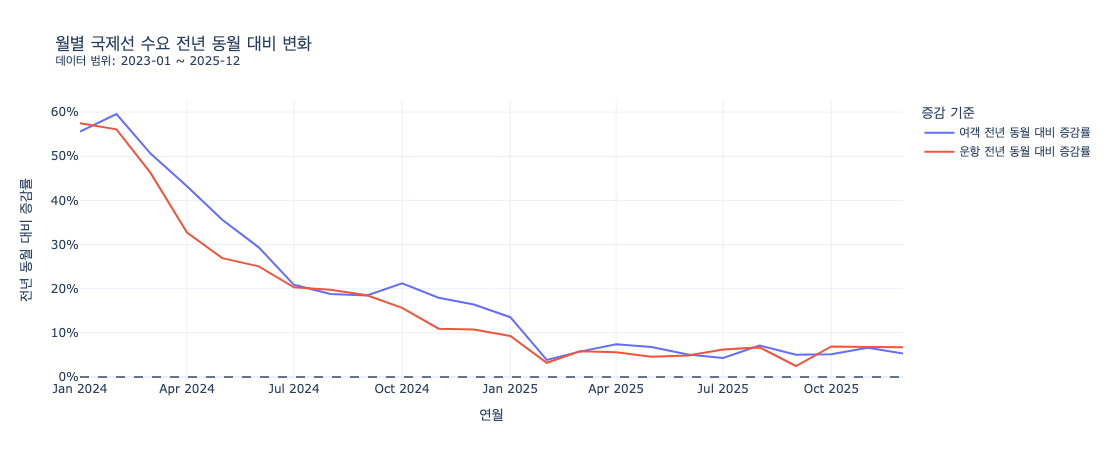

In [9]:
# 차트: 월별 여객·운항의 전년 동월 대비 증감률을 비교한다.
demand_yoy_chart = monthly_demand_df.copy()
demand_yoy_chart['기준월'] = pd.to_datetime(demand_yoy_chart['연월'], format='%Y%m')
demand_yoy_long = demand_yoy_chart.melt(
    id_vars='기준월',
    value_vars=['여객 전년 동월 대비 증감률', '운항 전년 동월 대비 증감률'],
    var_name='증감 기준',
    value_name='전년 동월 대비 증감률',
).dropna(subset=['전년 동월 대비 증감률'])

fig = px.line(
    demand_yoy_long,
    x='기준월',
    y='전년 동월 대비 증감률',
    color='증감 기준',
    title=chart_title('월별 국제선 수요 전년 동월 대비 변화', demand_yoy_chart['연월']),
    labels={'기준월': '연월'},
    template=PLOTLY_TEMPLATE,
)
fig.add_hline(y=0, line_dash='dash', line_color='#64748B')
fig.update_yaxes(tickformat='.0%')
fig.update_layout(height=460, legend_title_text='증감 기준')
fig.show(config={'displaylogo': False})


In [10]:
yearly_airport_demand_df = query('yearly_airport_demand_metrics')
display(yearly_airport_demand_df)


,연도,3개년 누적 순위,3개년 누적 여객 수,출발공항 표준값,여객 수,여객 비중,전년 여객 수,여객 전년 대비 증감률
0,2023,1,99501308.0,인천,27753553.0,0.8129,NaN,NaN
1,2024,1,99501308.0,인천,35154357.0,0.7916,27753553.0,0.2667
2,2025,1,99501308.0,인천,36593398.0,0.7749,35154357.0,0.0409
3,2023,2,12910339.0,김해,3236809.0,0.0948,NaN,NaN
4,2024,2,12910339.0,김해,4464629.0,0.1005,3236809.0,0.3793
5,2025,2,12910339.0,김해,5208901.0,0.1103,4464629.0,0.1667
6,2023,3,5772279.0,김포,1602338.0,0.0469,NaN,NaN
7,2024,3,5772279.0,김포,1961751.0,0.0442,1602338.0,0.2243
8,2025,3,5772279.0,김포,2208190.0,0.0468,1961751.0,0.1256
9,2023,4,3296225.0,제주,587200.0,0.0172,NaN,NaN


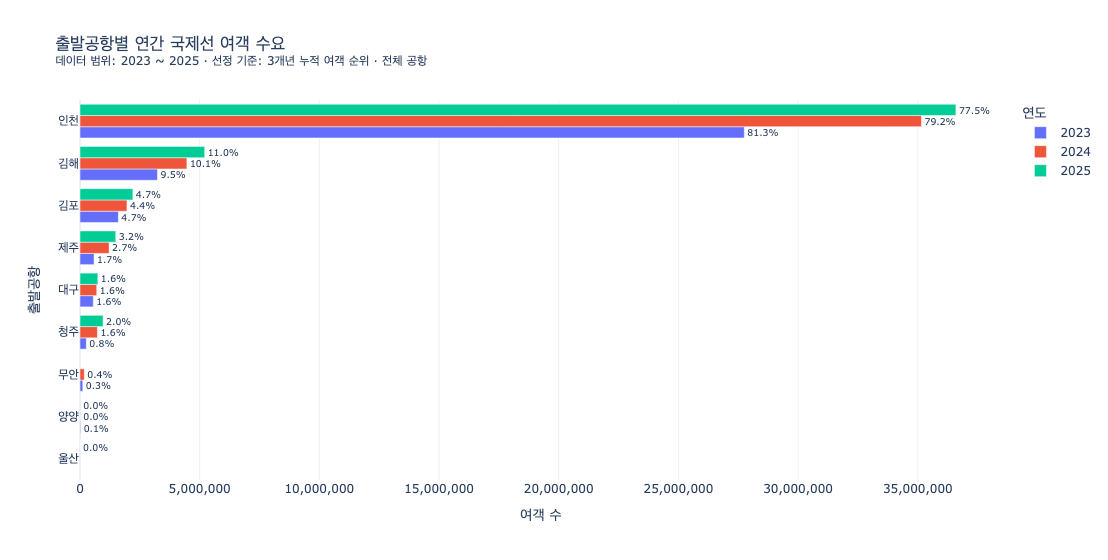

In [11]:
# 차트: 출발공항별 연간 국제선 여객 수를 3개년 누적 순위로 비교한다.
airport_demand_chart = yearly_airport_demand_df.copy()
airport_demand_chart['연도'] = airport_demand_chart['연도'].astype(str)
airport_order = (
    airport_demand_chart[['3개년 누적 순위', '출발공항 표준값']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['출발공항 표준값']
    .tolist()
)
fig = px.bar(
    airport_demand_chart,
    x='여객 수',
    y='출발공항 표준값',
    color='연도',
    text='여객 비중',
    barmode='group',
    orientation='h',
    title=chart_title(
        '출발공항별 연간 국제선 여객 수요',
        airport_demand_chart['연도'],
        '선정 기준: 3개년 누적 여객 순위 · 전체 공항',
    ),
    labels={'출발공항 표준값': '출발공항'},
    hover_data={
        '3개년 누적 여객 수': ':,',
        '여객 비중': ':.2%',
        '여객 전년 대비 증감률': ':.2%',
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_yaxes(categoryorder='array', categoryarray=airport_order[::-1])
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_layout(
    height=560, legend_title_text='연도',
    uniformtext_minsize=9, uniformtext_mode='hide',
)
fig.show(config={'displaylogo': False})


In [12]:
yearly_country_demand_df = query('yearly_country_demand_metrics')
display(yearly_country_demand_df.head(5))


,연도,3개년 누적 순위,3개년 누적 여객 수,지역 원문,국가 원문,여객 수,여객 비중,전년 여객 수,여객 전년 대비 증감률
0,2023,1,35894431.0,일본,일본,9694848.0,0.2840,NaN,NaN
1,2024,1,35894431.0,일본,일본,12558880.0,0.2828,9694848.0,0.2954
2,2025,1,35894431.0,일본,일본,13640703.0,0.2889,12558880.0,0.0861
3,2023,2,18580666.0,중국,중국,3369863.0,0.0987,NaN,NaN
4,2024,2,18580666.0,중국,중국,6841940.0,0.1541,3369863.0,1.0303


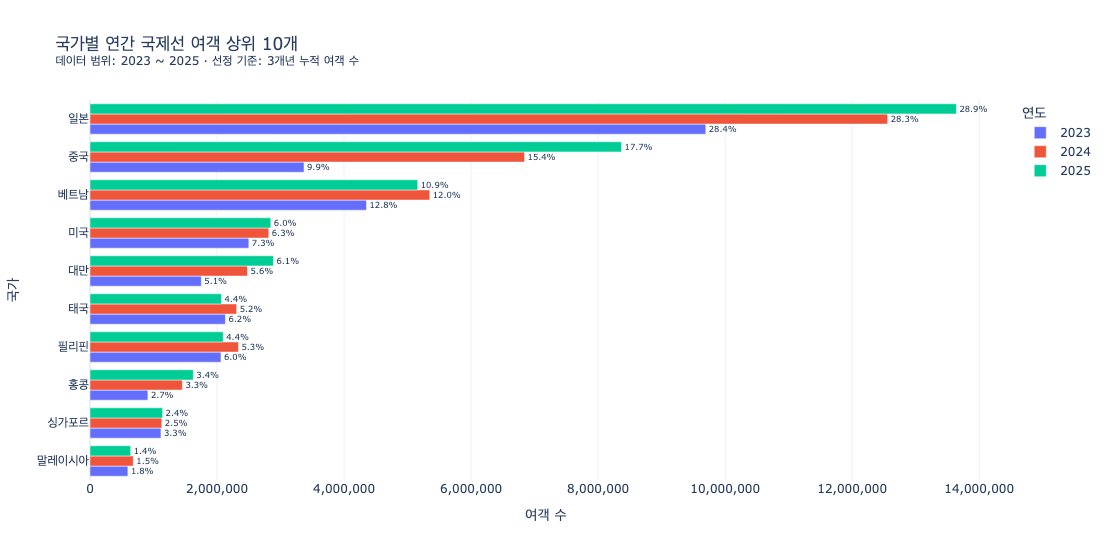

In [13]:
# 차트: 3개년 누적 여객 상위 10개 국가의 연간 수요를 비교한다.
country_demand_chart = yearly_country_demand_df.copy()
country_demand_chart['연도'] = country_demand_chart['연도'].astype(str)
country_order = (
    country_demand_chart[['3개년 누적 순위', '국가 원문']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['국가 원문']
    .tolist()
)
fig = px.bar(
    country_demand_chart,
    x='여객 수',
    y='국가 원문',
    color='연도',
    text='여객 비중',
    barmode='group',
    orientation='h',
    title=chart_title(
        '국가별 연간 국제선 여객 상위 10개',
        country_demand_chart['연도'],
        '선정 기준: 3개년 누적 여객 수',
    ),
    labels={'국가 원문': '국가'},
    hover_data={
        '지역 원문': True,
        '3개년 누적 여객 수': ':,',
        '여객 비중': ':.2%',
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_yaxes(categoryorder='array', categoryarray=country_order[::-1])
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_layout(height=560, legend_title_text='연도')
fig.show(config={'displaylogo': False})


In [14]:
yearly_destination_demand_df = query('yearly_destination_demand_metrics')
display(yearly_destination_demand_df.head(5))


,연도,3개년 누적 순위,3개년 누적 여객 수,목적지 대표 표준값,여객 수,운항편 수,여객 비중,편당 여객 수,전년 여객 수,여객 전년 대비 증감률,전년 운항편 수,운항 전년 대비 증감률
0,2023,1,10074906.0,간사이,2958140.0,15827.0,0.0866,186.90,NaN,NaN,NaN,NaN
1,2024,1,10074906.0,간사이,3499844.0,18606.0,0.0788,188.10,2958140.0,0.1831,15827.0,0.1756
2,2025,1,10074906.0,간사이,3616922.0,20287.0,0.0766,178.29,3499844.0,0.0335,18606.0,0.0903
3,2023,2,8028573.0,도쿄나리타,2193165.0,12690.0,0.0642,172.83,NaN,NaN,NaN,NaN
4,2024,2,8028573.0,도쿄나리타,2929036.0,16181.0,0.0660,181.02,2193165.0,0.3355,12690.0,0.2751


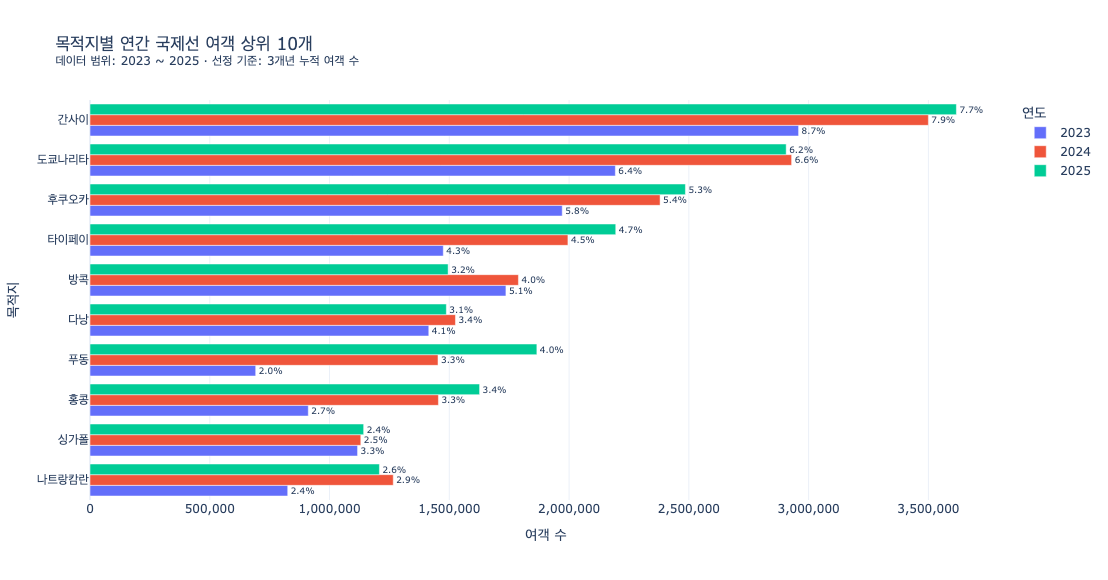

In [15]:
# 차트: 3개년 누적 여객 상위 10개 목적지의 연간 수요를 비교한다.
destination_demand_chart = yearly_destination_demand_df.copy()
destination_demand_chart['연도'] = destination_demand_chart['연도'].astype(str)
destination_order = (
    destination_demand_chart[['3개년 누적 순위', '목적지 대표 표준값']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['목적지 대표 표준값']
    .tolist()
)
fig = px.bar(
    destination_demand_chart,
    x='여객 수',
    y='목적지 대표 표준값',
    color='연도',
    text='여객 비중',
    barmode='group',
    orientation='h',
    title=chart_title(
        '목적지별 연간 국제선 여객 상위 10개',
        destination_demand_chart['연도'],
        '선정 기준: 3개년 누적 여객 수',
    ),
    labels={'목적지 대표 표준값': '목적지'},
    hover_data={
        '3개년 누적 여객 수': ':,',
        '운항편 수': ':,',
        '여객 비중': ':.2%',
        '편당 여객 수': ':.1f',
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_yaxes(categoryorder='array', categoryarray=destination_order[::-1])
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_layout(height=580, legend_title_text='연도')
fig.show(config={'displaylogo': False})


In [16]:
yearly_route_demand_df = query('yearly_route_demand_metrics')
display(yearly_route_demand_df.head(5))


,연도,3개년 누적 순위,3개년 누적 여객 수,출발공항 표준값,목적지 대표 표준값,여객 수,운항편 수,여객 비중,편당 여객 수,전년 여객 수,여객 전년 대비 증감률,전년 운항편 수,운항 전년 대비 증감률
0,2023,1,6519958.0,인천,도쿄나리타,1823120.0,10333.0,0.0534,176.44,NaN,NaN,NaN,NaN
1,2024,1,6519958.0,인천,도쿄나리타,2403840.0,12954.0,0.0541,185.57,1823120.0,0.3185,10333.0,0.2537
2,2025,1,6519958.0,인천,도쿄나리타,2292998.0,12478.0,0.0486,183.76,2403840.0,-0.0461,12954.0,-0.0367
3,2023,2,6339941.0,인천,간사이,1898630.0,9974.0,0.0556,190.36,NaN,NaN,NaN,NaN
4,2024,2,6339941.0,인천,간사이,2220213.0,11427.0,0.0500,194.30,1898630.0,0.1694,9974.0,0.1457


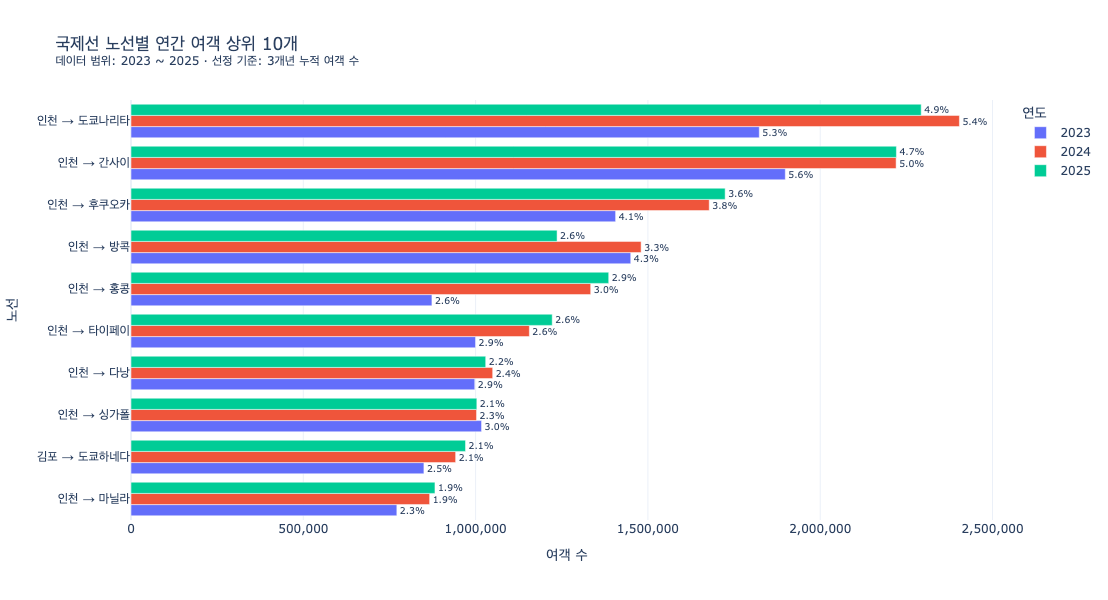

In [17]:
# 차트: 3개년 누적 여객 상위 10개 노선의 연간 수요를 비교한다.
route_demand_chart = yearly_route_demand_df.copy()
route_demand_chart['연도'] = route_demand_chart['연도'].astype(str)
route_demand_chart['노선'] = (
    route_demand_chart['출발공항 표준값'].fillna('(NULL)')
    + ' → '
    + route_demand_chart['목적지 대표 표준값'].fillna('(NULL)')
)
route_order = (
    route_demand_chart[['3개년 누적 순위', '노선']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['노선']
    .tolist()
)
fig = px.bar(
    route_demand_chart,
    x='여객 수',
    y='노선',
    color='연도',
    text='여객 비중',
    barmode='group',
    orientation='h',
    title=chart_title(
        '국제선 노선별 연간 여객 상위 10개',
        route_demand_chart['연도'],
        '선정 기준: 3개년 누적 여객 수',
    ),
    hover_data={
        '3개년 누적 여객 수': ':,',
        '운항편 수': ':,',
        '여객 비중': ':.2%',
        '편당 여객 수': ':.1f',
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_yaxes(categoryorder='array', categoryarray=route_order[::-1])
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_layout(height=600, legend_title_text='연도')
fig.show(config={'displaylogo': False})


### 월별 수요 관찰

월별 여객 수와 전년 동월 대비 증감률을 함께 보면 전체 수요는 확대되는 흐름이지만 증가 폭은 월마다 일정하지 않다. 따라서 2023~2025년의 증가를 하나의 고정 성장률로 연장하기보다 월별 계절성과 최근 증가 속도를 분리해 보는 것이 적절하다. 추천 서비스에서도 누적 인기와 최근 변화를 같은 의미의 순위로 다루지 않아야 한다.

> ### 가설 1 관찰 결과
>
> **가설 — 여객이 많은 공항·국가·목적지·노선은 전체 수요에서 차지하는 비중이 크고, 그 비중은 해마다 달라질 것이다.**
>
> **판정 — 관찰 범위에서 가설의 예상 방향과 일치했다.** 다만 상위 시장의 개별 비중과 변화가 관찰된 것이며, 전체 시장 집중도 자체를 판정한 것은 아니다.
>
> **관찰 결과 — 상위 시장의 개별 비중이 크게 관찰됐다. 출발공항 중 3개년 누적 여객 1위인 인천의 연간 비중은 2023년 81.29%에서 2025년 77.49%로 낮아졌다.**
>
> - **확인된 근거:** 인천은 3개년 누적 여객 9,950만 명으로 가장 크고, 일본·간사이·인천→도쿄 나리타가 국가·목적지·노선의 누적 1위였다.
> - **가능성 해석:** 2024년 1·2월 여객 증가율은 전년 동월 대비 55.59%·59.58%로 크게 나타났다. 외부 관광통계에서 2023년 국민 해외여행객은 2019년의 79.1% 수준으로 집계됐으므로, 2024년 초 증가율에는 실제 수요 확대와 함께 회복기였던 2023년을 비교 기준으로 삼은 기저효과가 반영됐을 가능성이 있다. 다만 외부 통계와 본 자료의 모집단은 다르고, 본 분석에는 2019~2022년 데이터가 없어 회복 효과의 크기를 분리할 수 없다. ([관광지식정보시스템](https://know.tour.go.kr/ptourknow/knowplus/kChannel/kChannelPeriod/kChannelPeriodDetail19Re.do?seq=103296))
> - **비즈니스 인사이트:** 인천은 3개년 누적 여객 1위를 유지했지만 연간 여객 비중은 2023년 81.29%에서 2025년 77.49%로 낮아졌다. 누적 규모가 큰 시장도 비중은 변할 수 있으므로 고정된 인기 순위와 최근 변화를 구분해 해석한다.
> - **해석상 한계:** 현재 표는 각 차원의 상위 순위와 개별 비중을 보여주며, HHI와 같은 지수로 시장 전체의 집중도를 검증한 결과는 아니다.

---

## 2. 계절별 목적지 분석

3개 연도 모두 관측된 목적지를 대상으로 월별 평균 수요 상위 5개와 연도별 평균 대비 계절 지수를 계산한다.

**가설 2.** 주요 목적지는 월마다 상대적으로 수요가 높은 시기가 서로 다를 것이다.

**가설 수립 근거 — [`03_eda.ipynb`](03_eda.ipynb) §2.** 전체 국제선 수요는 12월과 7·8월의 계절 지수가 높았지만, 전체 집계만으로는 목적지별 월별 상대 수요 차이를 알 수 없다.

**확인 방법.** 3개 연도 모두 관측된 목적지의 연도별 평균 대비 월별 계절 지수를 3개년 평균으로 집계하고, 월별 평균 수요 상위 목적지의 상대 수요 패턴을 비교한다.


In [18]:
seasonal_destination_df = query('seasonal_destination_metrics')
display(seasonal_destination_df.head(5))


,월,목적지 대표 표준값,관측 연도 수,평균 여객 수,최소 여객 수,최대 여객 수,평균 여객 계절 지수,평균 운항편 수,수요 순위
0,01,간사이,3,275182.0,201845.0,322454.0,0.9738,1434.0,1
1,01,도쿄나리타,3,214936.0,148676.0,263036.0,0.9515,1203.0,2
2,01,후쿠오카,3,189172.0,161885.0,208598.0,0.9953,977.0,3
3,01,방콕,3,174275.0,165078.0,188576.0,1.2531,689.0,4
4,01,타이페이,3,142045.0,79503.0,181915.0,0.8774,706.0,5


In [19]:
# 차트: 월별 상위 목적지의 연도별 월평균 대비 계절 지수를 비교한다.
seasonal_heatmap = seasonal_destination_df.pivot_table(
    index='목적지 대표 표준값',
    columns='월',
    values='평균 여객 계절 지수',
    aggfunc='mean',
)
fig = px.imshow(
    seasonal_heatmap,
    aspect='auto',
    color_continuous_scale='RdYlBu_r',
    zmin=0.8,
    zmax=1.3,
    text_auto='.2f',
    title=chart_title('월별 인기 목적지 계절 지수', monthly_demand_df['연월']),
    labels={'x': '월', 'y': '목적지', 'color': '연도별 월평균 대비 지수'},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=520)
fig.show(config={'displaylogo': False})

# 차트: 각 목적지가 월별 여객 상위 5위에 포함된 월 수를 집계한다.
seasonal_top_months = (
    seasonal_destination_df.groupby('목적지 대표 표준값', as_index=False)
    .agg(상위_5위_진입_월수=('월', 'nunique'))
    .nlargest(10, '상위_5위_진입_월수')
    .sort_values('상위_5위_진입_월수')
)
fig = px.bar(
    seasonal_top_months,
    x='상위_5위_진입_월수',
    y='목적지 대표 표준값',
    orientation='h',
    text='상위_5위_진입_월수',
    title=chart_title(
        '월별 여객 상위 5위 진입 횟수',
        monthly_demand_df['연월'],
        note='월별 순위 기준, 최대 12개월',
    ),
    labels={
        '목적지 대표 표준값': '목적지',
        '상위_5위_진입_월수': '상위 5위에 포함된 월 수',
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(dtick=1, range=[0, 12.8])
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(height=520, showlegend=False, margin={'r': 90})
fig.show(config={'displaylogo': False})


> ### 가설 2 관찰 결과
>
> **가설 — 주요 목적지는 월마다 상대적으로 수요가 높은 시기가 서로 다를 것이다.**
>
> **판정 — 관찰 범위에서 가설의 예상 방향과 일치했다.** 목적지별 월별 상대 수요 차이는 확인됐지만, 같은 패턴의 장기적인 반복 여부까지 판정한 것은 아니다.
>
> **관찰 결과 — 주요 목적지의 월별 상대 수요에 차이가 나타났다. 3개년 누적 여객 1위 목적지이면서 12개월 모두 월별 여객 상위 5위에 포함된 간사이는 12월의 3개년 평균 계절 지수가 1.1742였다.**
>
> - **확인된 근거:** 간사이·도쿄 나리타·후쿠오카는 여러 달에 걸쳐 월평균 여객 상위권에 포함됐지만 목적지별 월별 상대 수준은 같지 않았다.
> - **가능성 해석:** 방콕의 계절 지수는 12월 1.2126·1월 1.2531로 높고 5월 0.8476·6월 0.8589로 낮았다. 태국관광청은 태국의 겨울을 건조하고 선선한 바람이 부는 시기로 설명하므로, 한국의 겨울과 현지의 상대적으로 쾌적한 여행 시기가 겹친 점이 수요 패턴에 영향을 준 후보 요인일 수 있다. 다만 가격·휴일·좌석 공급을 통제한 결과는 아니다. ([태국관광청 기후 안내](https://www.tourismthailand.org/Plan-Your-Trip/Weather))
> - **비즈니스 인사이트:** 간사이의 12월 계절지수는 1.1742였고, 방콕은 1월 1.2531에서 5월 0.8476으로 월별 차이가 나타났다. 계절지수는 항공사 품질이 아니라 여행 시점에 따른 목적지 탐색 정보로 활용한다.
> - **해석상 한계:** 3개년 평균은 관찰 기간의 월별 상대 수요 차이를 보여주지만 장기적으로 같은 패턴이 반복된다고 확정하지 않는다. 향후 2026년 실제값이 확보되면 같은 월별 패턴이 유지되는지 다시 확인한다.

---

## 3. 성장 목적지 분석

2024년과 2025년 모두 12개월이 관측되고 비교 연도 여객이 0보다 큰 목적지만 비교한다.

**가설 3.** 최근 여객이 늘어난 목적지 중에는 여객 증가율과 운항편 증가율이 서로 다른 곳이 있을 것이다.

**분석 관점.** 증가율만 높은 소규모 시장과 실제 증가 여객 수가 큰 시장을 구분하고, 여객 증가와 운항 증가의 폭도 함께 본다.

**가설 수립 근거 — §1.** 누적 순위는 규모가 큰 기존 시장을 보여주지만 최근 증가 폭이 큰 목적지를 별도로 드러내지 못할 수 있다. 최근 성장 후보를 추린 뒤 목적지별 여객 증가율과 운항 증가율의 차이를 확인한다.

**확인 방법.** 2024년과 2025년이 모두 12개월 관측되고 비교 연도 여객이 0보다 큰 목적지에서 여객·운항 증가 수와 증가율을 함께 비교한다.


In [20]:
growth_destination_df = query('growth_destination_metrics')
display(growth_destination_df.head(5))


,목적지 대표 표준값,최신 연도,비교 연도,최신 연도 관측 월 수,비교 연도 관측 월 수,최신 연도 여객 수,비교 연도 여객 수,최신 연도 운항편 수,비교 연도 운항편 수,여객 증가 수,여객 증가율,운항 증가 수,운항 증가율
0,푸동,2025,2024,12,12,1865525.0,1452818.0,11849.0,10299.0,412707.0,0.2841,1550.0,0.1505
1,타이페이,2025,2024,12,12,2194821.0,1995187.0,10419.0,9691.0,199634.0,0.1001,728.0,0.0751
2,홍콩,2025,2024,12,12,1626343.0,1454544.0,9416.0,9269.0,171799.0,0.1181,147.0,0.0159
3,청도,2025,2024,12,12,910626.0,745852.0,6521.0,5813.0,164774.0,0.2209,708.0,0.1218
4,나고야,2025,2024,12,12,716572.0,564569.0,4147.0,3333.0,152003.0,0.2692,814.0,0.2442


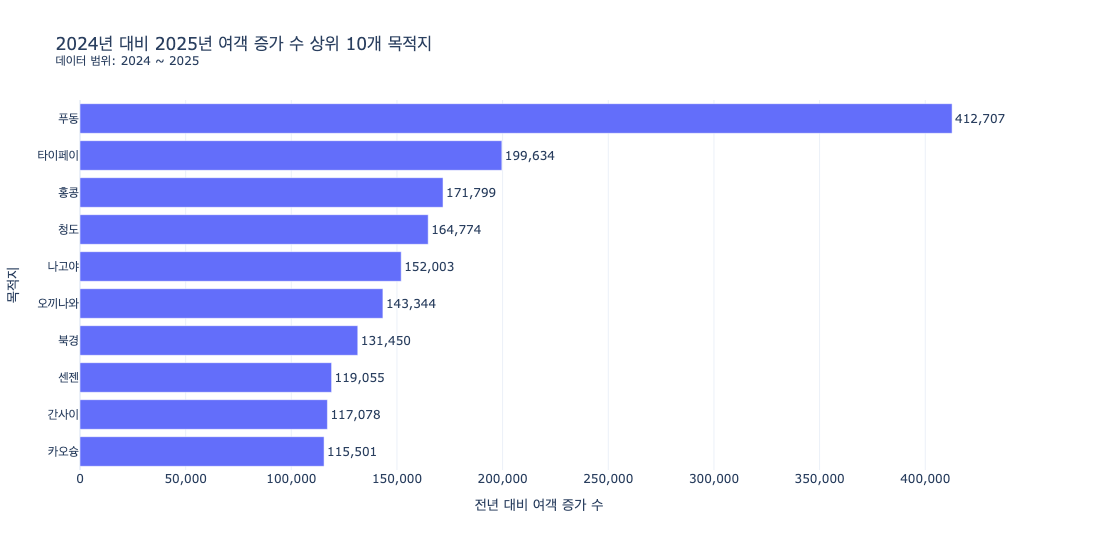

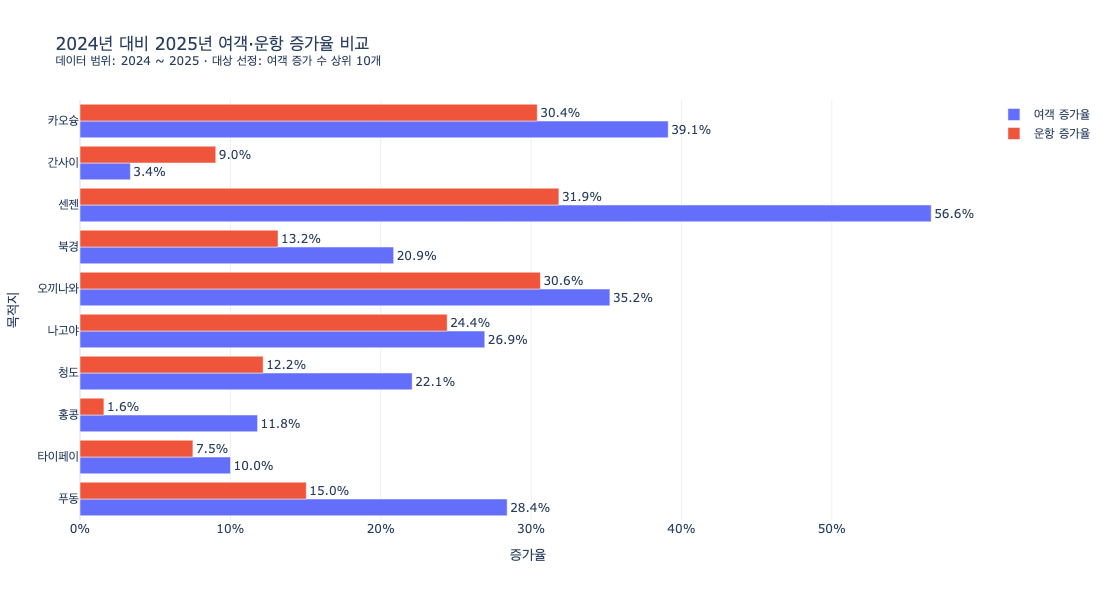

In [21]:
# 차트: 최신 연도 여객 증가 수가 큰 목적지 10개를 비교한다.
growth_chart = growth_destination_df.head(10).sort_values('여객 증가 수')
comparison_year_label = _format_chart_period(growth_chart['비교 연도'].iloc[0])
latest_year_label = _format_chart_period(growth_chart['최신 연도'].iloc[0])
fig = px.bar(
    growth_chart,
    x='여객 증가 수',
    y='목적지 대표 표준값',
    orientation='h',
    text='여객 증가 수',
    title=chart_title(
        f'{comparison_year_label}년 대비 {latest_year_label}년 여객 증가 수 상위 10개 목적지',
        [growth_chart['비교 연도'].iloc[0], growth_chart['최신 연도'].iloc[0]],
    ),
    labels={'목적지 대표 표준값': '목적지', '여객 증가 수': '전년 대비 여객 증가 수'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside', cliponaxis=False)
fig.update_layout(height=550, showlegend=False, margin={'r': 110})
fig.show(config={'displaylogo': False})

# 차트: 같은 10개 목적지에서 여객 증가율과 운항 증가율을 직접 비교한다.
growth_rate_chart = growth_chart[[
    '목적지 대표 표준값', '여객 증가율', '운항 증가율'
]].melt(
    id_vars='목적지 대표 표준값',
    var_name='증가율 구분',
    value_name='증가율',
)
fig = px.bar(
    growth_rate_chart,
    x='증가율',
    y='목적지 대표 표준값',
    color='증가율 구분',
    barmode='group',
    orientation='h',
    title=chart_title(
        f'{comparison_year_label}년 대비 {latest_year_label}년 여객·운항 증가율 비교',
        [growth_chart['비교 연도'].iloc[0], growth_chart['최신 연도'].iloc[0]],
        note='대상 선정: 여객 증가 수 상위 10개',
    ),
    labels={'목적지 대표 표준값': '목적지'},
    category_orders={
        '목적지 대표 표준값': growth_chart['목적지 대표 표준값'].tolist(),
        '증가율 구분': ['여객 증가율', '운항 증가율'],
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.0%')
fig.update_traces(texttemplate='%{x:.1%}', textposition='outside', cliponaxis=False)
fig.update_layout(height=600, legend_title_text='')
fig.show(config={'displaylogo': False})


> ### 가설 3 관찰 결과
>
> **가설 — 최근 여객이 늘어난 목적지 중에는 여객 증가율과 운항편 증가율이 서로 다른 곳이 있을 것이다.**
>
> **판정 — 관찰 범위에서 가설의 예상 방향과 일치했다.** 여객 증가 수 1위인 푸동에서 증가율 차이가 확인됐으며, 모든 성장 목적지가 같은 패턴이라고 판정한 것은 아니다.
>
> **관찰 결과 — 2024년 대비 2025년 여객 증가 수 1위인 푸동에서 여객 증가율 28.41%와 운항 증가율 15.05%의 차이가 나타났다.**
>
> - **확인된 근거:** 푸동은 여객이 412,707명 늘어 증가 수가 가장 컸고, 타이페이와 홍콩의 여객 증가 수는 각각 199,634명과 171,799명이었다. 푸동은 예상한 증가율 차이가 관찰된 대표 사례다.
> - **가능성 해석:** 여객 증가 수 상위 10개에는 푸동·청도·북경·센젠 등 중국 본토 목적지 4곳이 포함됐다. 중국이 2024년 11월 한국 일반여권 소지자에게 단기 무비자 입국을 허용하고 같은 달 말 체류 기간을 30일로 늘린 시점과 2025년 중국 도시의 여객 증가가 겹치므로, 입국 절차 완화가 여행 진입 장벽을 낮춘 후보 요인일 수 있다. 다만 본 자료는 여객 국적과 방문 목적을 구분하지 않고 가격·좌석 공급도 포함하지 않으므로 정책 효과로 단정하지 않는다. ([주한 중국대사관](https://kr.china-embassy.gov.cn/kor/lsfw/lszj/202411/t20241104_11520712.htm), [중국 외교부](https://www.mfa.gov.cn/eng/xw/fyrbt/lxjzh/202412/t20241217_11495778.html))
> - **비즈니스 인사이트:** 푸동은 2024년 대비 2025년 여객이 412,707명 증가했지만 여객 증가율 28.41%와 운항 증가율 15.05%는 다르게 나타났다. 최근 성장 후보에는 증가 인원·증가율·운항 증가 폭을 함께 제시하고, 이를 항공사 운항 품질과 분리해 해석한다.
> - **해석상 한계:** 푸동의 결과를 모든 성장 목적지에 일반화하지 않는다. 운항편 수는 좌석 공급량이나 탑승률이 아니므로 공급 부족·수익성으로 확대 해석하지 않으며, 최근 증가의 지속 여부는 2026년 실제값으로 별도 확인한다.


### 3-1. 보조 분석 질문 — 대륙별로 인기 있는 방문 도시와 떠오르는 도시는 어디인가?

전체 목적지 순위는 아시아 수요가 큰 구조를 명확히 보여주지만, 유럽·미주·대양주·중동 안에서 어떤 도시가 핵심 수요와 최근 성장의 중심인지까지 설명하지는 못한다. 따라서 프로젝트의 목적지-지역 표준 매핑을 기준으로 대륙을 나누고, **대륙별 인기 방문 도시 Top 10**과 **대륙별 떠오르는 도시 Top 10**을 분리해 확인한다.

**질문 수립 근거 — §1·§3.** 누적 인기 순위는 큰 시장을, 최근 여객 증가 수 순위는 변화가 큰 시장을 보여준다. 두 기준을 대륙 안에서 다시 계산하면 전체 순위에서 가려지는 지역별 핵심 도시와 성장 후보를 비교할 수 있다.

**확인 방법.** 인기 도시는 2023~2025년 누적 여객 수로, 떠오르는 도시는 2024년 대비 2025년 여객 증가 수로 순위를 매긴다. 성장 순위는 두 연도가 모두 12개월 관측되고 2024년 여객 수가 0보다 큰 목적지 중 증가 수가 양수인 경우만 포함한다. 목적지-지역 표준 매핑에 연결되지 않은 값은 대륙 비교에서 제외하고 별도 한계로 남긴다.


In [22]:
# 대륙별 목적지 분석용 데이터: 수요 뷰와 프로젝트의 표준 목적지-지역 매핑을 결합한다.
destination_region_map_path = ROOT / 'config' / '05_destination_region_map.csv'
destination_region_map_df = (
    pd.read_csv(destination_region_map_path)
    .rename(columns={
        'destination_canonical_std': '목적지 대표 표준값',
        'country': '국가',
        'region': '지역',
    })
)

continent_by_region = {
    '동북아': '아시아',
    '동남아': '아시아',
    '남아시아': '아시아',
    '중앙아시아': '아시아',
    '유럽': '유럽',
    '미주': '미주',
    '대양주': '대양주',
    '중동': '중동',
}
destination_region_map_df['대륙'] = (
    destination_region_map_df['지역'].map(continent_by_region).fillna('미분류')
)

continent_destination_monthly_df = pd.read_sql(
    text('''
        SELECT period_ym, destination_canonical_std, passengers, operations
        FROM v_metric_demand_destination_monthly
        ORDER BY period_ym, destination_canonical_std
    '''),
    engine,
).rename(columns={
    'period_ym': '연월',
    'destination_canonical_std': '목적지 대표 표준값',
    'passengers': '여객 수',
    'operations': '운항편 수',
})
continent_destination_monthly_df['연도'] = continent_destination_monthly_df['연월'].astype(str).str[:4].astype(int)
continent_destination_monthly_df = continent_destination_monthly_df.merge(
    destination_region_map_df[['목적지 대표 표준값', '국가', '지역', '대륙']],
    on='목적지 대표 표준값',
    how='left',
)
continent_destination_monthly_df['대륙'] = continent_destination_monthly_df['대륙'].fillna('미분류')

# 표준 매핑에 연결된 목적지만 대륙 간 순위에 사용한다.
analysis_destination_monthly_df = continent_destination_monthly_df.query("대륙 != '미분류'").copy()
continent_order = ['아시아', '유럽', '미주', '대양주', '중동']
continent_colors = {
    '아시아': '#4F86B5',
    '유럽': '#776FA8',
    '미주': '#C9677A',
    '대양주': '#E8A33D',
    '중동': '#2A8C82',
}

continent_popular_top10_df = (
    analysis_destination_monthly_df
    .groupby(['대륙', '목적지 대표 표준값', '국가'], as_index=False)
    .agg(**{'누적 여객 수': ('여객 수', 'sum'), '누적 운항편 수': ('운항편 수', 'sum')})
)
continent_popular_top10_df['대륙 내 인기 순위'] = (
    continent_popular_top10_df.groupby('대륙')['누적 여객 수']
    .rank(method='first', ascending=False)
    .astype(int)
)
continent_popular_top10_df = (
    continent_popular_top10_df.query('`대륙 내 인기 순위` <= 10')
    .sort_values(['대륙', '대륙 내 인기 순위'])
    .reset_index(drop=True)
)

destination_yearly_df = (
    analysis_destination_monthly_df
    .groupby(['대륙', '목적지 대표 표준값', '국가', '연도'], as_index=False)
    .agg(관측월수=('연월', 'nunique'), 여객_수=('여객 수', 'sum'), 운항편_수=('운항편 수', 'sum'))
)
latest_year = destination_yearly_df['연도'].max()
previous_year = latest_year - 1
latest_destination_yearly_df = destination_yearly_df.query('연도 == @latest_year').rename(columns={
    '관측월수': '최신 연도 관측월수',
    '여객_수': '최신 연도 여객 수',
    '운항편_수': '최신 연도 운항편 수',
})
previous_destination_yearly_df = destination_yearly_df.query('연도 == @previous_year').rename(columns={
    '관측월수': '비교 연도 관측월수',
    '여객_수': '비교 연도 여객 수',
    '운항편_수': '비교 연도 운항편 수',
})
continent_growth_top10_df = latest_destination_yearly_df.merge(
    previous_destination_yearly_df.drop(columns='연도'),
    on=['대륙', '목적지 대표 표준값', '국가'],
    how='inner',
)
continent_growth_top10_df = continent_growth_top10_df.query(
    '`최신 연도 관측월수` == 12 and `비교 연도 관측월수` == 12 and `비교 연도 여객 수` > 0'
)
continent_growth_top10_df['여객 증가 수'] = (
    continent_growth_top10_df['최신 연도 여객 수'] - continent_growth_top10_df['비교 연도 여객 수']
)
continent_growth_top10_df['여객 증가율'] = (
    continent_growth_top10_df['여객 증가 수'] / continent_growth_top10_df['비교 연도 여객 수']
)
continent_growth_top10_df = continent_growth_top10_df.query('`여객 증가 수` > 0').copy()
continent_growth_top10_df['대륙 내 성장 순위'] = (
    continent_growth_top10_df.groupby('대륙')['여객 증가 수']
    .rank(method='first', ascending=False)
    .astype(int)
)
continent_growth_top10_df = (
    continent_growth_top10_df.query('`대륙 내 성장 순위` <= 10')
    .sort_values(['대륙', '대륙 내 성장 순위'])
    .reset_index(drop=True)
)

def show_continent_destination_chart(data, continent, rank_col, value_col, analysis_name, period_values, note=None):
    chart_data = data.query('대륙 == @continent').sort_values(rank_col, ascending=False)
    if chart_data.empty:
        fig = go.Figure()
        fig.add_annotation(
            text=f'{continent}에서 조건을 충족하는 목적지가 없습니다.',
            x=0.5, y=0.5, xref='paper', yref='paper', showarrow=False,
        )
        fig.update_layout(
            title=chart_title(f'{continent} {analysis_name}', period_values, note),
            height=300, template=PLOTLY_TEMPLATE,
        )
        fig.show(config={'displaylogo': False})
        return

    hover_data = {'국가': True, rank_col: True}
    if '여객 증가율' in chart_data.columns:
        hover_data['여객 증가율'] = ':.1%'

    fig = px.bar(
        chart_data,
        x=value_col,
        y='목적지 대표 표준값',
        orientation='h',
        text=value_col,
        color_discrete_sequence=[continent_colors[continent]],
        title=chart_title(
            f'{continent} {analysis_name} Top {len(chart_data)}',
            period_values,
            note,
        ),
        labels={'목적지 대표 표준값': '방문 도시'},
        hover_data=hover_data,
        template=PLOTLY_TEMPLATE,
    )
    fig.update_xaxes(tickformat=',')
    fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside', cliponaxis=False)
    fig.update_layout(height=460, showlegend=False, margin={'r': 115})
    fig.show(config={'displaylogo': False})


#### 대륙별 인기 방문 도시 Top 10

누적 여객 수 기준으로 대륙 안에서 가장 큰 수요를 보인 도시를 각각 확인한다.


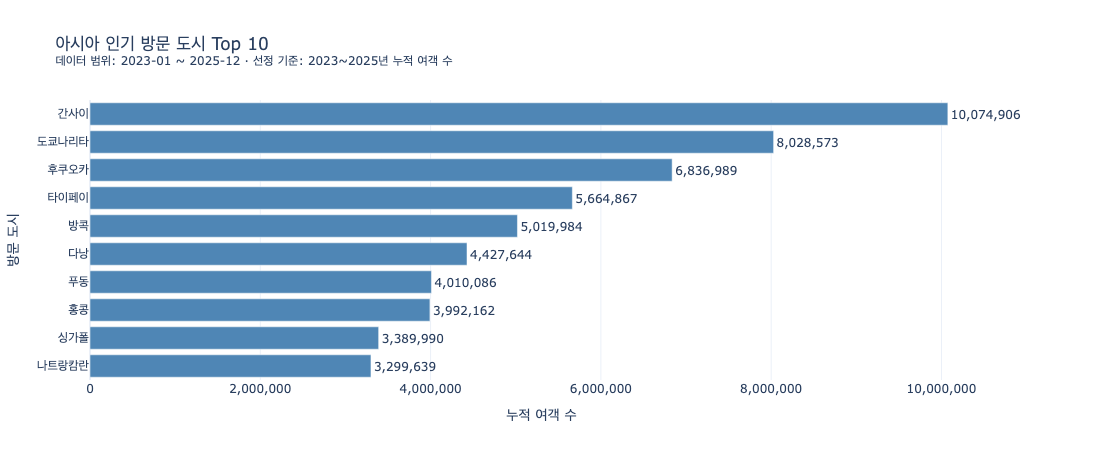

In [23]:
show_continent_destination_chart(
    continent_popular_top10_df,
    '아시아',
    rank_col='대륙 내 인기 순위',
    value_col='누적 여객 수',
    analysis_name='인기 방문 도시',
    period_values=analysis_destination_monthly_df['연월'],
    note='선정 기준: 2023~2025년 누적 여객 수',
)


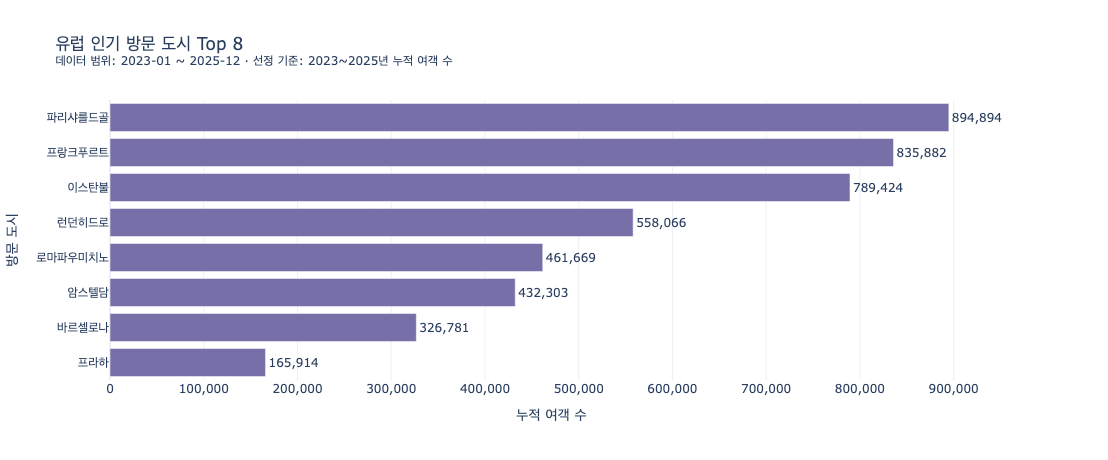

In [24]:
show_continent_destination_chart(
    continent_popular_top10_df,
    '유럽',
    rank_col='대륙 내 인기 순위',
    value_col='누적 여객 수',
    analysis_name='인기 방문 도시',
    period_values=analysis_destination_monthly_df['연월'],
    note='선정 기준: 2023~2025년 누적 여객 수',
)


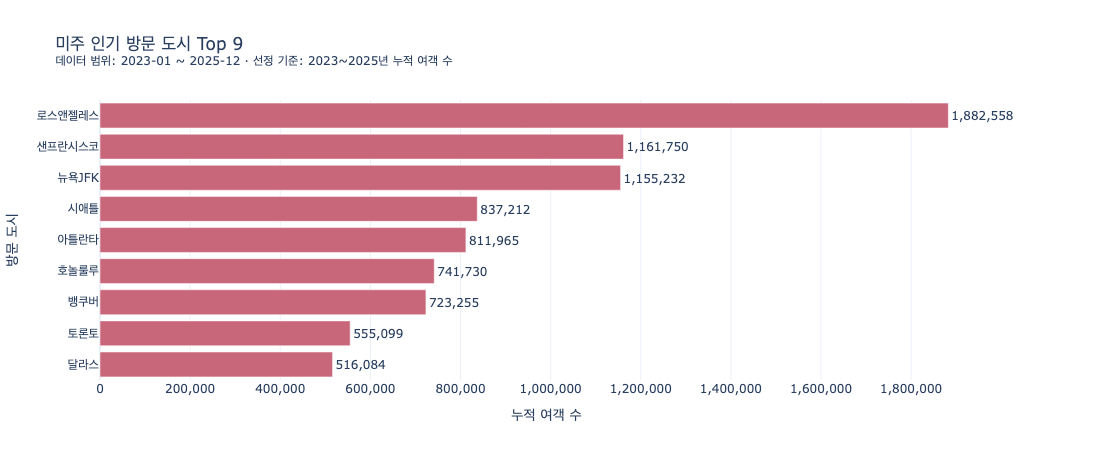

In [25]:
show_continent_destination_chart(
    continent_popular_top10_df,
    '미주',
    rank_col='대륙 내 인기 순위',
    value_col='누적 여객 수',
    analysis_name='인기 방문 도시',
    period_values=analysis_destination_monthly_df['연월'],
    note='선정 기준: 2023~2025년 누적 여객 수',
)


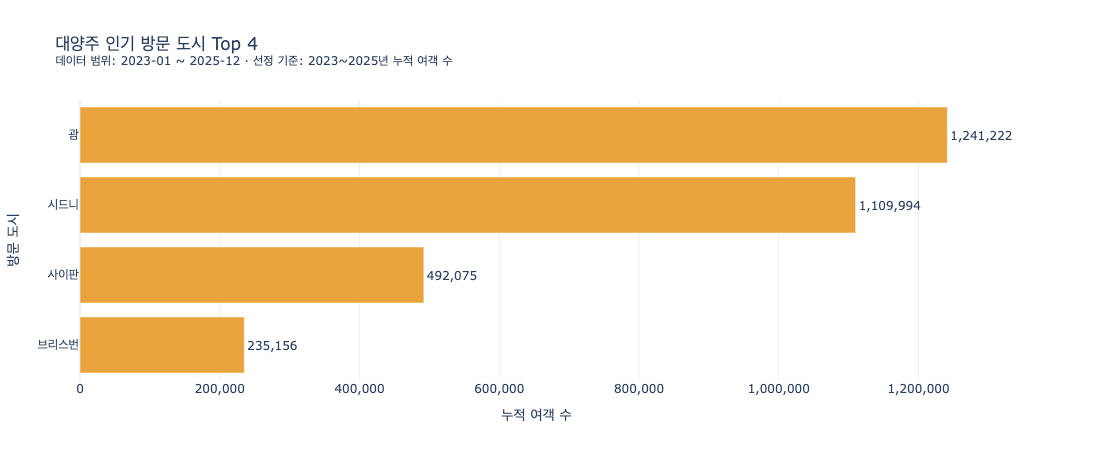

In [26]:
show_continent_destination_chart(
    continent_popular_top10_df,
    '대양주',
    rank_col='대륙 내 인기 순위',
    value_col='누적 여객 수',
    analysis_name='인기 방문 도시',
    period_values=analysis_destination_monthly_df['연월'],
    note='선정 기준: 2023~2025년 누적 여객 수',
)


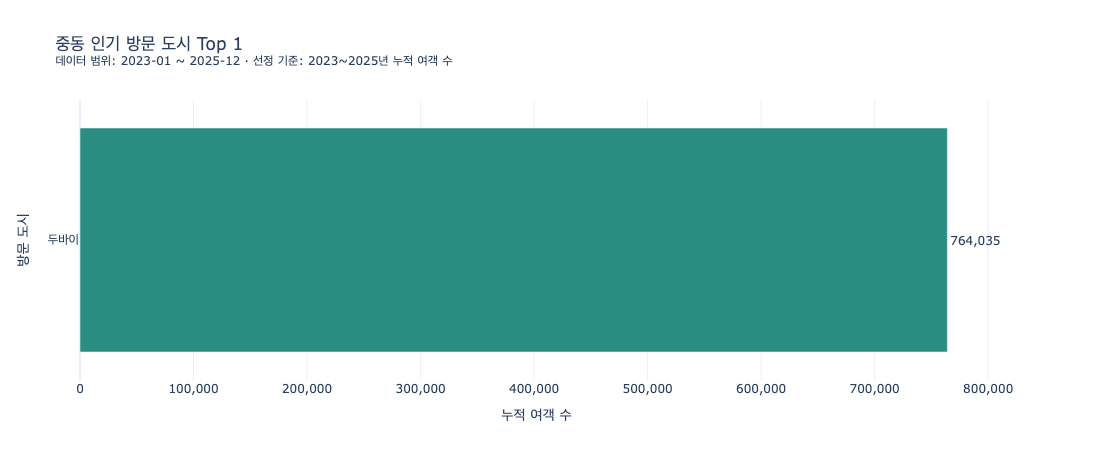

In [27]:
show_continent_destination_chart(
    continent_popular_top10_df,
    '중동',
    rank_col='대륙 내 인기 순위',
    value_col='누적 여객 수',
    analysis_name='인기 방문 도시',
    period_values=analysis_destination_monthly_df['연월'],
    note='선정 기준: 2023~2025년 누적 여객 수',
)


#### 대륙별 떠오르는 도시 Top 10

2024년 대비 2025년 여객 증가 수가 양수인 목적지만 대상으로, 대륙 안에서 증가 폭이 큰 도시를 확인한다.


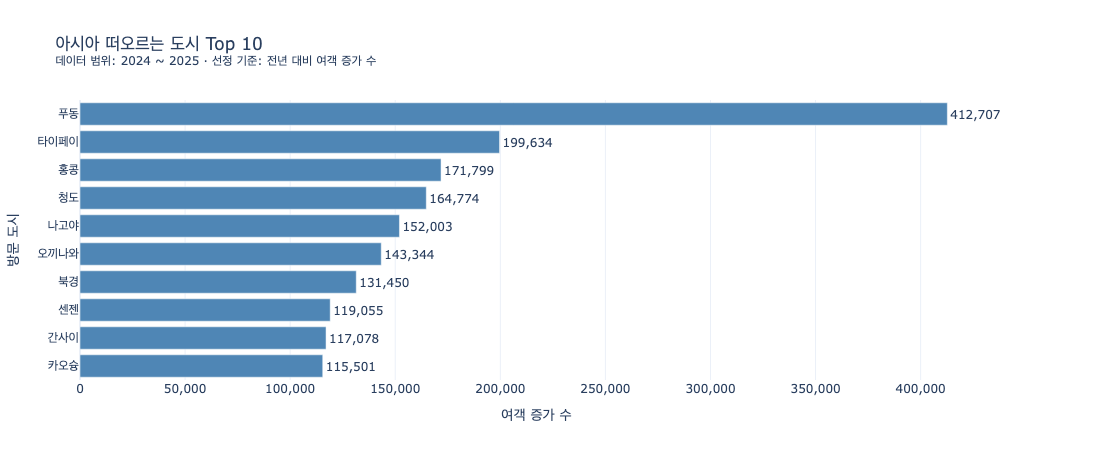

In [28]:
show_continent_destination_chart(
    continent_growth_top10_df,
    '아시아',
    rank_col='대륙 내 성장 순위',
    value_col='여객 증가 수',
    analysis_name='떠오르는 도시',
    period_values=[previous_year, latest_year],
    note='선정 기준: 전년 대비 여객 증가 수',
)


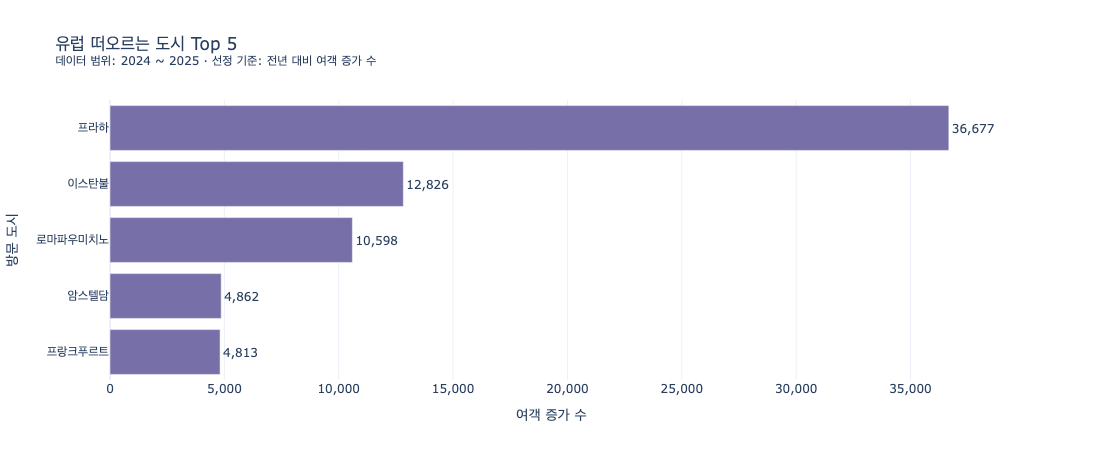

In [29]:
show_continent_destination_chart(
    continent_growth_top10_df,
    '유럽',
    rank_col='대륙 내 성장 순위',
    value_col='여객 증가 수',
    analysis_name='떠오르는 도시',
    period_values=[previous_year, latest_year],
    note='선정 기준: 전년 대비 여객 증가 수',
)


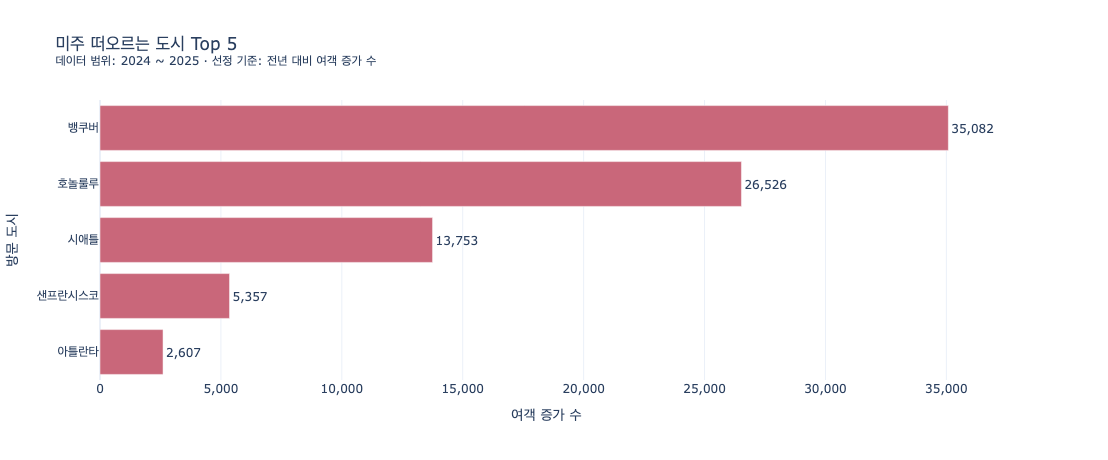

In [30]:
show_continent_destination_chart(
    continent_growth_top10_df,
    '미주',
    rank_col='대륙 내 성장 순위',
    value_col='여객 증가 수',
    analysis_name='떠오르는 도시',
    period_values=[previous_year, latest_year],
    note='선정 기준: 전년 대비 여객 증가 수',
)


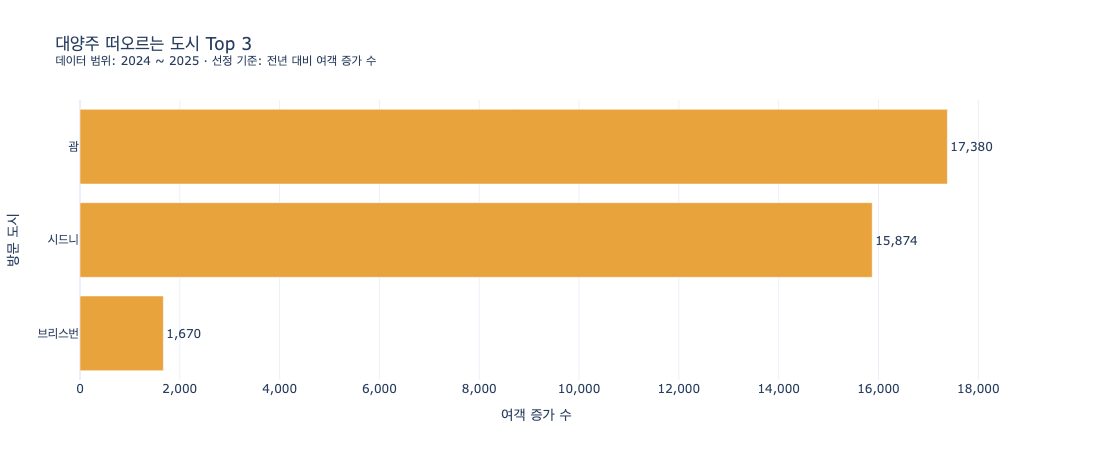

In [31]:
show_continent_destination_chart(
    continent_growth_top10_df,
    '대양주',
    rank_col='대륙 내 성장 순위',
    value_col='여객 증가 수',
    analysis_name='떠오르는 도시',
    period_values=[previous_year, latest_year],
    note='선정 기준: 전년 대비 여객 증가 수',
)


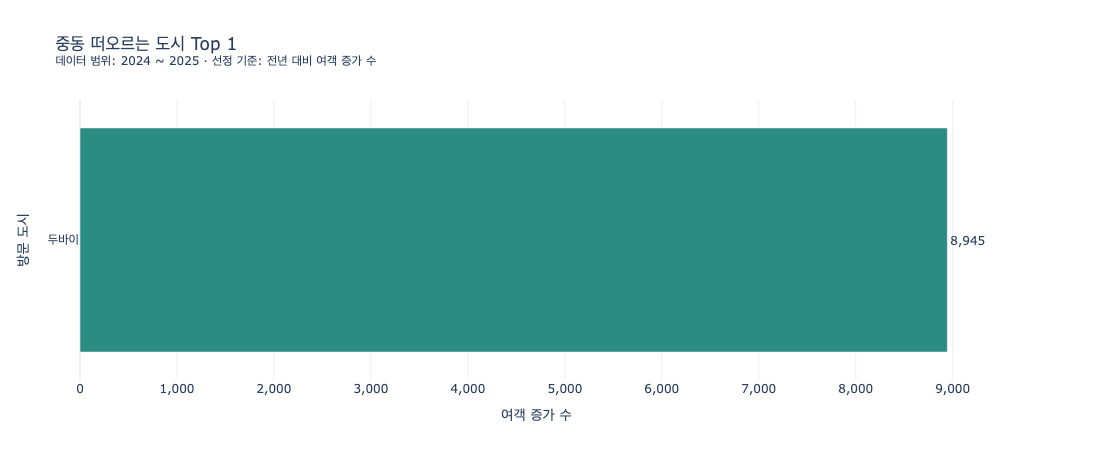

In [32]:
show_continent_destination_chart(
    continent_growth_top10_df,
    '중동',
    rank_col='대륙 내 성장 순위',
    value_col='여객 증가 수',
    analysis_name='떠오르는 도시',
    period_values=[previous_year, latest_year],
    note='선정 기준: 전년 대비 여객 증가 수',
)


> ### 보조 분석 질문 관찰 결과
>
> **핵심 결과 — 전체 수요는 아시아에 집중돼 있지만, 대륙별 순위로 나누면 지역마다 서로 다른 핵심 도시와 성장 후보가 확인됐다.** 아시아의 누적 수요 상위 3개 도시는 오사카 간사이 1,007만 명, 도쿄 나리타 803만 명, 후쿠오카 684만 명이었다. 유럽에서는 파리 샤를드골(89만 명)·프랑크푸르트(84만 명)·이스탄불(79만 명), 미주에서는 로스앤젤레스(188만 명)·샌프란시스코(116만 명)·뉴욕 JFK(116만 명)가 각 대륙의 상위권을 형성했다.
>
> - **최근 성장:** 아시아에서는 상하이 푸둥이 2024년 대비 41만 명 증가해 가장 큰 증가 폭을 보였고, 타이베이(+20만 명)·홍콩(+17만 명)·칭다오(+16만 명)가 뒤를 이었다. 유럽은 프라하(+3.7만 명), 미주는 밴쿠버(+3.5만 명), 대양주는 괌(+1.7만 명)이 각 대륙의 증가 수 1위였다.
> - **비즈니스 인사이트:** 전체 인기 순위만으로 캠페인 후보를 고르면 아시아 도시 중심으로 해석이 쏠린다. 대륙을 먼저 선택하고 그 안에서 누적 인기와 최근 성장을 함께 보면, 유럽의 프라하나 미주의 밴쿠버처럼 전체 순위에서는 두드러지지 않는 지역별 확장 후보를 별도로 발견할 수 있다.
> - **활용 방식:** 대륙 선택 후 `인기 방문 도시`는 재방문·얼리버드 등 수요 전환형 메시지에, `떠오르는 도시`는 여행 콘텐츠·검색 수요 확보 등 인지도 확장형 메시지에 연결한다. 다만 증가 수는 수요 변화이지 수익성·좌석 공급·정책 효과를 직접 보여주지 않는다.
> - **해석상 한계:** 현재 표준 목적지-지역 매핑은 275개 목적지 중 89개에 연결된다. 매핑되지 않은 186개 목적지는 대륙 순위에서 제외했으므로, 이 분석은 매핑된 목적지 범위의 비교이며 미분류 목적지를 포함한 전체 시장의 완전한 대륙별 순위로 일반화하지 않는다.

---

## 4. 운항 안정성 분석

인천·김포 출발 국제선 여객편 로그를 월·공항·목적지 단위로 집계하고, 상태 지연과 15분 시간 지연을 별도로 본다. 네 운항 지표 뷰는 상태·시간 지연의 분자·분모, 취소·회항, 15분 지연편 평균 지연시간을 공통으로 제공한다. 월·공항 뷰에는 전체 출발시간 차이와 중앙 지연시간도 포함하고, 상태 미상·자정 보정 건수는 검증 쿼리에서만 확인한다.

> **지표 용어 안내**
>
> - **상태 지연률**: 분모는 상태가 `출발` 또는 `지연`인 편이며, 이 가운데 원본 상태가 `지연`으로 기록된 편을 분자로 한다.
> - **15분 시간 지연률**: 분모는 상태가 `출발` 또는 `지연`이면서 시간 계산이 가능한 편이며, 이 가운데 보정된 실제-계획 출발시간 차이가 15분 이상인 편을 분자로 한다.
> - **상태 `NULL` 처리**: 상태가 비어 있는 편은 상태 지연률과 15분 시간 지연률의 분모에서 모두 제외한다.
> - **출발시간의 의미**: 본 자료의 `출발시간`은 활주로에서 바퀴가 뜬 실제 이륙 시각이라기보다 게이트·주기장을 떠난 시각에 가까운 값으로 해석한다. 인천공항 운항정보는 출발 상태의 시각을 “비행기가 게이트에서 출발한 시간”으로 안내하고, A-CDM 매뉴얼은 AOBT(실제 주기장 출발시간)를 실제 푸시백 시각으로 정의하며 ATOT(실제 이륙시간)와 구분한다. 따라서 이 노트북의 출발시간 차이와 15분 시간 지연률은 **활주로 이륙 지연이 아니라 게이트·주기장 출발 기준의 지연**으로 읽는다. ([인천공항 출발시간 안내](https://airport.kr/ap_ko/869/subview.do), [인천공항 A-CDM 운영매뉴얼](https://www.airport.kr/sites/co_ko/down/A-CDM_Operation_Manual_KOR.pdf))
> - **해석상 주의**: 15분 시간 지연률은 계획 대비 실제 게이트·주기장 출발시간의 차이를 보여주는 결과 지표다. 탑승 절차, 연결편 대기, 지상조업, 공항 혼잡, 기상·항공교통 흐름 등 항공사 외 요인이 함께 반영될 수 있으며, 현재 데이터로 각 요인의 영향을 분리할 수 없다. 따라서 이 지표를 항공사의 귀책이나 서비스 품질로 직접 해석하지 않는다.

**보조 분석 질문.** 상태 지연률과 15분 시간 지연률은 실제로 얼마나 다르며, 하나의 지연률로 요약할 수 있는가?

**질문 수립 근거 — [`03_eda.ipynb`](03_eda.ipynb) §3.** 같은 분모에서 상태값 기준 지연 비율은 김포 7.28%·인천 30.57%, 15분 이상 시간차 비율은 김포 52.19%·인천 85.39%로 크게 달랐다. 04에서는 확정한 정의를 다시 선택하지 않고 월·공항·목적지에서도 격차가 유지되는지 확인한다.

**확인 방법.** 상태 지연률과 15분 시간 지연률을 동일한 월·공항·목적지에서 나란히 비교한다. 취소·회항은 별도 운항 결과로, 지연사유는 리스크 설명을 위한 보조 지표로 유지한다.


In [33]:
monthly_operation_df = query('monthly_operation_metrics')
display(monthly_operation_df.head(5))


,운항 연월,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,취소 편 수,회항 편 수,평균 실제-계획 출발시간 차이(분),15분 시간 지연편 평균 지연시간(분),상태 지연률,15분 시간 지연률,취소율,회항률,15분 시간 지연편 중앙 지연시간(분)
0,202301,9537,9354.0,3066.0,9336.0,7784.0,13.0,5.0,34.85,39.93,0.3278,0.8338,0.0014,0.0005,30.0
1,202302,8864,8672.0,1796.0,8654.0,6574.0,4.0,0.0,26.30,31.77,0.2071,0.7596,0.0005,0.0000,25.0
2,202303,10080,9909.0,1407.0,9898.0,7044.0,6.0,3.0,22.82,28.55,0.1420,0.7117,0.0006,0.0003,24.0
3,202304,11172,11099.0,1715.0,11088.0,8128.0,2.0,3.0,23.90,29.54,0.1545,0.7330,0.0002,0.0003,24.0
4,202305,12655,12629.0,1872.0,12629.0,9304.0,23.0,2.0,24.17,29.80,0.1482,0.7367,0.0018,0.0002,24.0


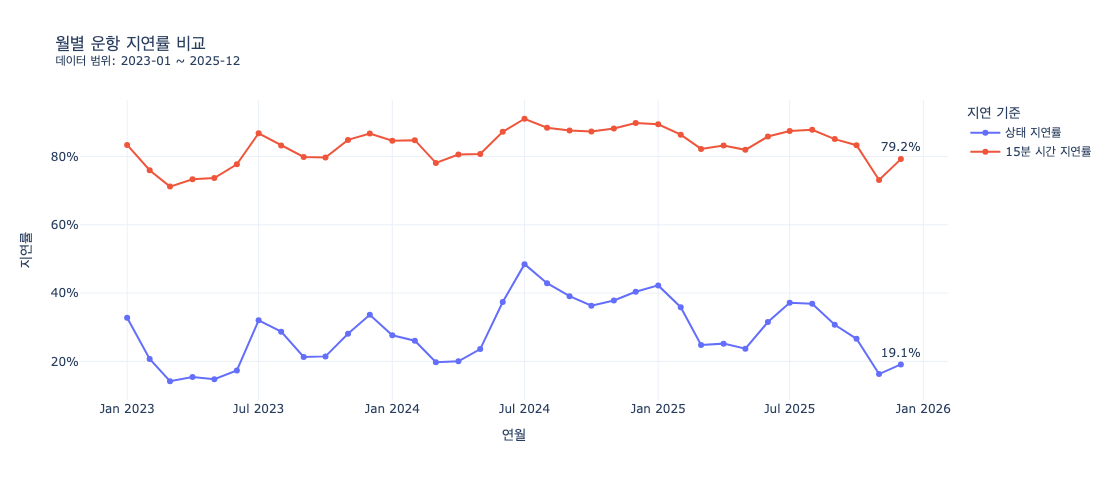

In [34]:
# 차트: 상태 지연률과 15분 시간 지연률의 월별 차이를 비교한다.
operation_chart = monthly_operation_df.copy()
operation_chart['기준월'] = pd.to_datetime(operation_chart['운항 연월'], format='%Y%m')
operation_rate_long = operation_chart.melt(
    id_vars='기준월',
    value_vars=['상태 지연률', '15분 시간 지연률'],
    var_name='지연 기준',
    value_name='지연률',
)
latest_operation_month = operation_rate_long['기준월'].max()
operation_rate_long['표시값'] = (
    operation_rate_long['지연률'].map(lambda value: f'{value:.1%}')
    .where(operation_rate_long['기준월'].eq(latest_operation_month), '')
)

fig = px.line(
    operation_rate_long,
    x='기준월',
    y='지연률',
    color='지연 기준',
    text='표시값',
    title=chart_title('월별 운항 지연률 비교', operation_chart['운항 연월']),
    labels={'기준월': '연월'},
    template=PLOTLY_TEMPLATE,
)
fig.update_yaxes(tickformat='.0%')
fig.update_traces(textposition='top center')
fig.update_layout(height=480, legend_title_text='지연 기준')
fig.show(config={'displaylogo': False})


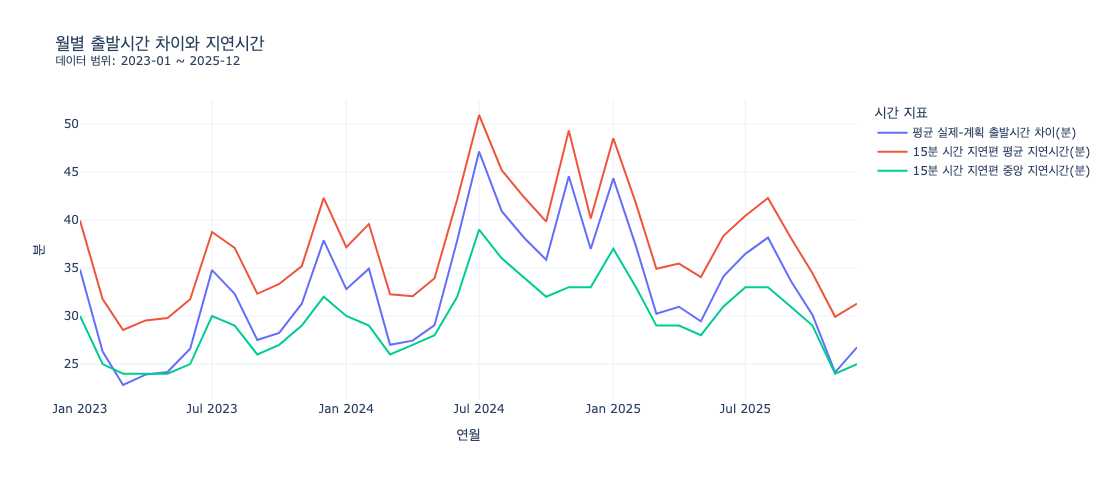

In [35]:
# 차트: 월별 평균 출발시간 차이와 15분 지연편의 평균·중앙 지연시간을 비교한다.
operation_gap_long = operation_chart.melt(
    id_vars=['기준월', '운항 연월'],
    value_vars=[
        '평균 실제-계획 출발시간 차이(분)',
        '15분 시간 지연편 평균 지연시간(분)',
        '15분 시간 지연편 중앙 지연시간(분)',
    ],
    var_name='시간 지표',
    value_name='분',
)
fig = px.line(
    operation_gap_long,
    x='기준월',
    y='분',
    color='시간 지표',
    title=chart_title('월별 출발시간 차이와 지연시간', operation_chart['운항 연월']),
    labels={'기준월': '연월'},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=480, legend_title_text='시간 지표')
fig.show(config={'displaylogo': False})


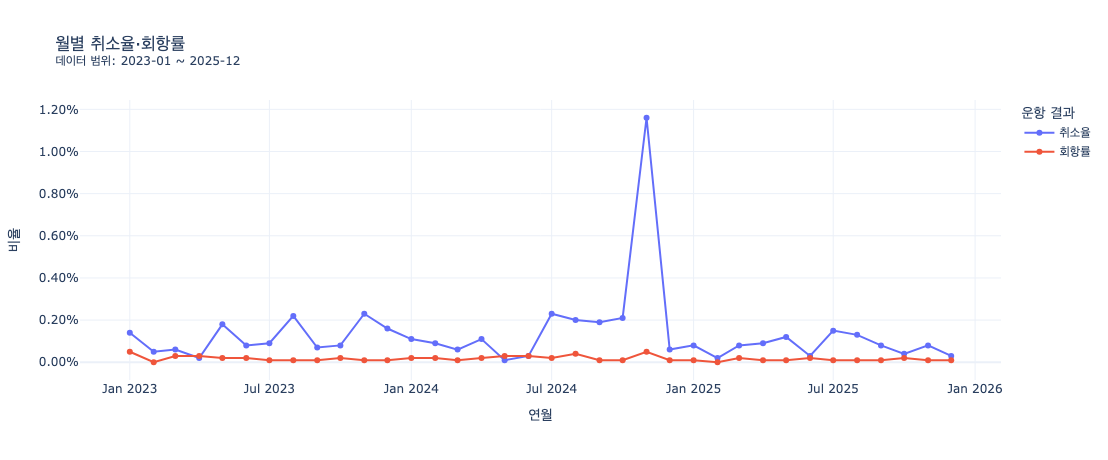

In [36]:
# 차트: 월별 취소율과 회항률을 별도 운항 결과로 비교한다.
operation_outcome_long = operation_chart.melt(
    id_vars=['기준월', '운항 연월'],
    value_vars=['취소율', '회항률'],
    var_name='운항 결과',
    value_name='비율',
)
fig = px.line(
    operation_outcome_long,
    x='기준월',
    y='비율',
    color='운항 결과',
    markers=True,
    title=chart_title('월별 취소율·회항률', operation_chart['운항 연월']),
    labels={'기준월': '연월'},
    template=PLOTLY_TEMPLATE,
)
fig.update_yaxes(tickformat='.2%')
fig.update_layout(height=460, legend_title_text='운항 결과')
fig.show(config={'displaylogo': False})


In [37]:
airport_operation_df = query('airport_operation_metrics')
display(airport_operation_df.head(5))


,운항 연월,출발공항 원문,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,취소 편 수,회항 편 수,평균 실제-계획 출발시간 차이(분),15분 시간 지연편 평균 지연시간(분),상태 지연률,15분 시간 지연률,취소율,회항률,15분 시간 지연편 중앙 지연시간(분)
0,202301,김포,464,463.0,37.0,461.0,162.0,0.0,0.0,16.15,29.43,0.0799,0.3514,0.0000,0.0000,21.0
1,202301,인천,9073,8891.0,3029.0,8875.0,7622.0,13.0,5.0,35.83,40.16,0.3407,0.8588,0.0014,0.0006,31.0
2,202302,김포,438,437.0,15.0,431.0,142.0,0.0,0.0,13.71,22.54,0.0343,0.3295,0.0000,0.0000,19.0
3,202302,인천,8426,8235.0,1781.0,8223.0,6432.0,4.0,0.0,26.96,31.97,0.2163,0.7822,0.0005,0.0000,25.5
4,202303,김포,589,589.0,15.0,587.0,198.0,0.0,0.0,13.00,20.47,0.0255,0.3373,0.0000,0.0000,18.0


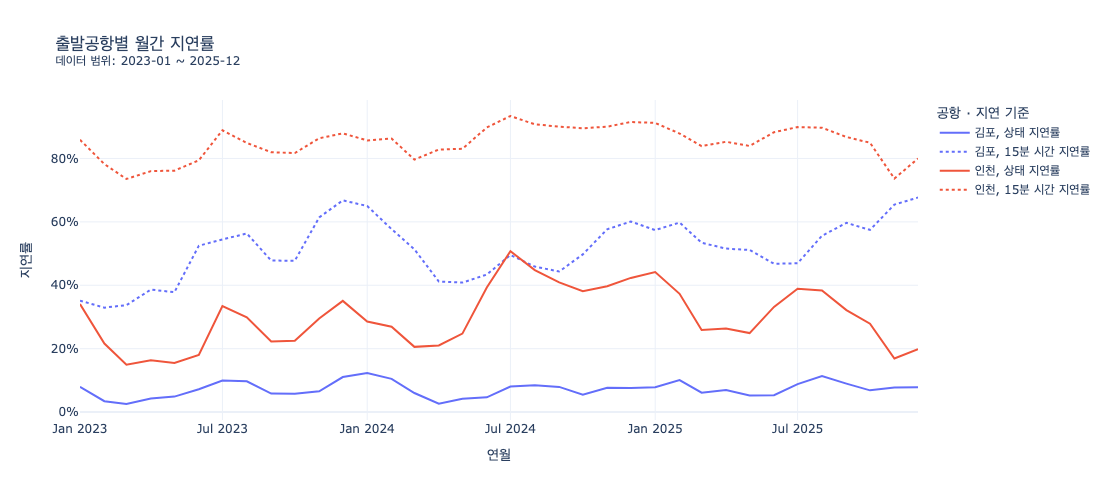

In [38]:
# 차트: 공항별 상태 지연률과 15분 시간 지연률의 월별 흐름을 비교한다.
airport_operation_chart = airport_operation_df.copy()
airport_operation_chart['기준월'] = pd.to_datetime(
    airport_operation_chart['운항 연월'], format='%Y%m'
)
airport_operation_long = airport_operation_chart.melt(
    id_vars=['기준월', '출발공항 원문'],
    value_vars=['상태 지연률', '15분 시간 지연률'],
    var_name='지연 기준',
    value_name='지연률',
)
fig = px.line(
    airport_operation_long,
    x='기준월',
    y='지연률',
    color='출발공항 원문',
    line_dash='지연 기준',
    title=chart_title('출발공항별 월간 지연률', airport_operation_chart['운항 연월']),
    labels={'기준월': '연월', '출발공항 원문': '출발공항'},
    template=PLOTLY_TEMPLATE,
)
fig.update_yaxes(tickformat='.0%')
fig.update_layout(height=500, legend_title_text='공항 · 지연 기준')
fig.show(config={'displaylogo': False})


In [39]:
yearly_destination_operation_df = query('yearly_destination_operation_metrics')
display(yearly_destination_operation_df.head(5))


,연도,3개년 누적 순위,3개년 누적 운항 로그 수,목적지 대표 표준값,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,상태 지연률,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,15분 시간 지연률,취소 편 수,취소율,회항 편 수,회항률,15분 시간 지연편 평균 지연시간(분)
0,2023,1,39404.0,간사이,11530.0,11436.0,2022.0,0.1768,11427.0,8975.0,0.7854,16.0,0.0014,2.0,0.0002,31.04
1,2024,1,39404.0,간사이,13285.0,13110.0,3956.0,0.3018,12950.0,10852.0,0.8380,21.0,0.0016,1.0,0.0001,38.63
2,2025,1,39404.0,간사이,14589.0,14576.0,3521.0,0.2416,14558.0,11633.0,0.7991,6.0,0.0004,1.0,0.0001,34.84
3,2023,2,31911.0,도쿄나리타,9078.0,9006.0,1792.0,0.1990,9002.0,7775.0,0.8637,3.0,0.0003,0.0,0.0000,31.07
4,2024,2,31911.0,도쿄나리타,11626.0,11487.0,4256.0,0.3705,11367.0,10552.0,0.9283,21.0,0.0018,1.0,0.0001,40.33


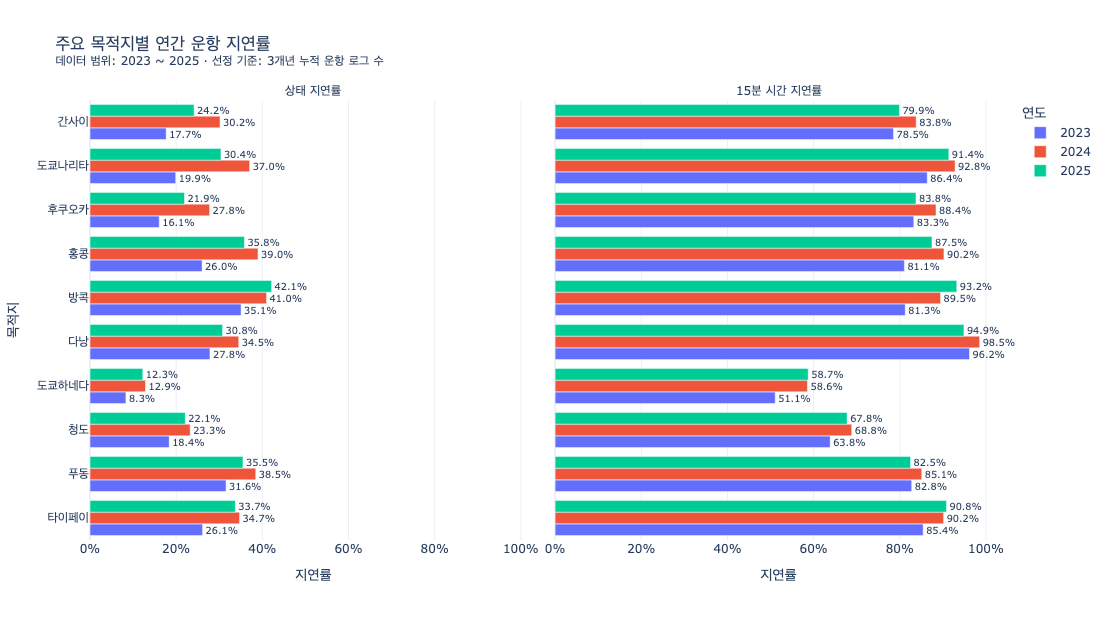

In [40]:
# 차트: 3개년 누적 운항 로그 상위 10개 목적지의 연도별 두 지연률을 비교한다.
destination_operation_chart = yearly_destination_operation_df.copy()
destination_operation_chart['연도'] = destination_operation_chart['연도'].astype(str)
destination_operation_order = (
    destination_operation_chart[['3개년 누적 순위', '목적지 대표 표준값']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['목적지 대표 표준값']
    .tolist()
)
destination_status = destination_operation_chart[
    ['목적지 대표 표준값', '연도', '상태 지연률']
].rename(columns={'상태 지연률': '지연률'})
destination_status['지연 기준'] = '상태 지연률'
destination_time = destination_operation_chart[
    ['목적지 대표 표준값', '연도', '15분 시간 지연률']
].rename(columns={'15분 시간 지연률': '지연률'})
destination_time['지연 기준'] = '15분 시간 지연률'
destination_operation_long = pd.concat(
    [destination_status, destination_time], ignore_index=True
)
fig = px.bar(
    destination_operation_long,
    x='지연률',
    y='목적지 대표 표준값',
    color='연도',
    text='지연률',
    facet_col='지연 기준',
    barmode='group',
    orientation='h',
    title=chart_title(
        '주요 목적지별 연간 운항 지연률',
        destination_operation_chart['연도'],
        '선정 기준: 3개년 누적 운항 로그 수',
    ),
    labels={'목적지 대표 표준값': '목적지'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.0%')
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_yaxes(
    categoryorder='array', categoryarray=destination_operation_order[::-1]
)
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.update_layout(height=620, legend_title_text='연도')
fig.show(config={'displaylogo': False})


In [41]:
delay_reason_df = query('delay_reason_metrics')
display(delay_reason_df)


,지연사유 분류,지연 편 수,지연사유 비중
0,항공기 연결에 의한 지연,55256.0,0.3555
1,공항 및 출입국 절차에 의한 지연,37904.0,0.2439
2,항공교통흐름에 의한 지연,34109.0,0.2195
3,여객 및 화물처리에 의한 지연,8848.0,0.0569
4,항공기 정비에 의한 지연,5515.0,0.0355
5,미입력,4653.0,0.0299
6,기상에 의한 지연,2680.0,0.0172
7,기타 원인에 의한 지연,2586.0,0.0166
8,운항 기준 및 승무원 관련 지연,2131.0,0.0137
9,지상조업 관련 지연,1671.0,0.0108


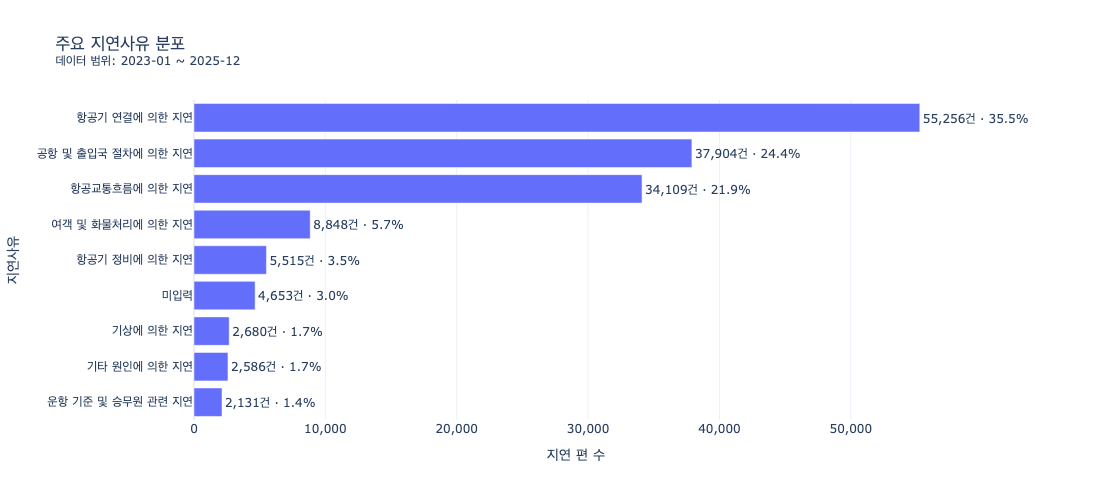

In [42]:
# 차트: 전체 기간의 주요 지연사유 비중을 비교한다.
reason_chart = delay_reason_df.nlargest(9, '지연 편 수').sort_values('지연 편 수')
reason_chart['표시값'] = reason_chart.apply(
    lambda row: f"{row['지연 편 수']:,.0f}건 · {row['지연사유 비중']:.1%}",
    axis=1,
)
fig = px.bar(
    reason_chart,
    x='지연 편 수',
    y='지연사유 분류',
    text='표시값',
    orientation='h',
    title=chart_title('주요 지연사유 분포', monthly_operation_df['운항 연월']),
    labels={'지연사유 분류': '지연사유'},
    hover_data={'지연사유 비중': ':.2%'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(height=500, showlegend=False, margin={'r': 150})
fig.show(config={'displaylogo': False})


> ### 보조 분석 질문 관찰 결과
>
> **핵심 결과 — 하나의 지연률로 요약할 수 있는지를 최신 관측 월로 확인한 결과, 2025년 12월 상태 지연률은 19.13%, 15분 시간 지연률은 79.22%로 60.09%p 차이가 나타나 두 지표를 분리해 해석해야 했다.**
>
> - 상태 지연률은 원본 상태가 `지연`으로 기록됐는지를 보고, 15분 시간 지연률은 시간 계산이 가능한 편의 실제-계획 출발시간 차이를 본다. 분모와 분자 조건이 다르므로 두 값은 같은 현상을 재측정한 대체 지표가 아니다.
> - 목적지 비교에서 3개년 누적 운항 로그 수 1위인 간사이에서도 상태 지연률은 2023년 17.68%·2024년 30.18%·2025년 24.16%였지만, 15분 시간 지연률은 같은 기간 78.54%·83.80%·79.91%로 계속 높았다. 따라서 두 지표의 차이는 최신 월의 전체 집계에서만 나타난 현상이 아니었다.
> - **가능성 해석:** 2024년 7월은 월간 여객이 395만 명으로 연중 높은 수준이었고, 상태 지연률 48.47%와 15분 시간 지연률 91.03%도 관찰 기간의 월별 최고치였다. 여름 성수기 수요와 기상·공항 혼잡·항공기 연결 등이 함께 작용했을 가능성은 있으나, 현재 자료에는 월별 기상·혼잡·연결편 자료가 없어 어느 요인의 영향인지 구분할 수 없다.
> - **비즈니스 인사이트:** 2025년 12월 상태 지연률 19.13%와 15분 시간 지연률 79.22% 사이에 60.09%p 차이가 나타났다. 두 지표를 평균내지 않고 분모 편 수와 함께 제공하되, 15분 지표가 목적지별 항공사 순위를 충분히 구분하는지는 현재 출력으로 확인되지 않았다.
> - 따라서 하나의 `지연률`을 선택하거나 두 값을 평균내지 않고, 추천 화면에서도 상태 지연·15분 시간 지연·취소·회항을 분리해 제공한다.
> - 이 결과는 원본 상태와 시간차 정의의 차이를 보여주며, 어느 지표가 더 정확한 운항 품질 척도인지를 판정한 결과는 아니다.

### 지연사유 관찰

전체 기간 지연사유 중 항공기 연결이 35.55%로 가장 큰 비중을 차지해 기록된 사유가 균등하게 분포하지는 않았다. 다만 이 비중은 입력된 사유의 구성비이며, 항공기 연결이 전체 지연을 그만큼 인과적으로 발생시켰다는 뜻은 아니다.


## 5. 수요와 운항 안정성 결합

항공사와 목적지는 연도 단위로 수요·안정성을 결합하고, 3개년 누적 규모로 비교 대상을 고정한다. 수요는 전국 출발 집계이고 안정성은 인천·김포 로그이므로, 결합 결과는 수요 대비 운항 특성을 비교하기 위한 것이며 두 자료의 운항편 수가 일치한다는 뜻은 아니다.

**가설 4.** 여객이 많거나 증가한 목적지·항공사라고 해서 지연률도 반드시 높거나 증가하지는 않을 것이다.

**분석 관점.** 인기·성장성과 운항 안정성 중 하나만으로 목적지·항공사를 평가하지 않고, 관찰 범위에서 두 축의 변화 방향이 항상 일치하는지를 함께 본다.

**가설 수립 근거 — [`03_eda.ipynb`](03_eda.ipynb) §2-§3.** 03에서 수요 확대와 공항별 지연 수준 차이가 각각 관찰됐지만 두 자료는 모집단이 다르다. 04에서는 인과관계를 검정하지 않고, 항공사·목적지별 연간 수요와 인천·김포에서 관찰된 운항 특성이 같은 방향으로만 움직이는지 비교한다.

**확인 방법.** 3개년 누적 수요 상위 항공사·목적지의 연간 여객 수와 상태 지연률·15분 시간 지연률을 나란히 제시하고, 같은 방향으로 움직이지 않은 사례가 있는지 확인한다.


In [43]:
# 3개년 누적 여객 상위 항공사의 연도별 수요와 인천·김포 운항 안정성을 비교한다.
airline_yearly_stability_df = query('airline_yearly_demand_stability_metrics')
display(airline_yearly_stability_df)

,연도,3개년 누적 순위,3개년 누적 여객 수,항공사 표준값,여객 수,운항편 수,전년 여객 수,여객 전년 대비 증감률,전년 운항편 수,운항 전년 대비 증감률,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,상태 지연률,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,15분 시간 지연률,취소 편 수,취소율,회항 편 수,회항률,15분 시간 지연편 평균 지연시간(분)
0,2023,1,25357276.0,대한항공,6968352.0,41383.0,NaN,NaN,NaN,NaN,32513.0,32210.0,7759.0,0.2409,32190.0,28177.0,0.8753,17.0,0.0005,7.0,0.0002,33.81
1,2024,1,25357276.0,대한항공,8811662.0,50543.0,6968352.0,0.2645,41383.0,0.2213,40643.0,40203.0,13977.0,0.3477,39895.0,37280.0,0.9345,99.0,0.0024,15.0,0.0004,39.33
2,2025,1,25357276.0,대한항공,9577262.0,52293.0,8811662.0,0.0869,50543.0,0.0346,41872.0,41850.0,12823.0,0.3064,41835.0,39273.0,0.9388,12.0,0.0003,1.0,0.0000,36.76
3,2023,2,16612376.0,아시아나항공,4508369.0,24170.0,NaN,NaN,NaN,NaN,20573.0,20542.0,4253.0,0.2070,20542.0,18371.0,0.8943,7.0,0.0003,7.0,0.0003,31.96
4,2024,2,16612376.0,아시아나항공,6020700.0,29733.0,4508369.0,0.3354,24170.0,0.2302,26373.0,26178.0,7532.0,0.2877,25922.0,23936.0,0.9234,40.0,0.0015,6.0,0.0002,36.51
5,2025,2,16612376.0,아시아나항공,6083307.0,29615.0,6020700.0,0.0104,29733.0,-0.0040,27697.0,27677.0,8280.0,0.2992,27671.0,26027.0,0.9406,16.0,0.0006,2.0,0.0001,36.76
6,2023,3,11848138.0,제주항공,3692707.0,23276.0,NaN,NaN,NaN,NaN,17233.0,17170.0,4676.0,0.2723,17149.0,14112.0,0.8229,9.0,0.0005,5.0,0.0003,34.38
7,2024,3,11848138.0,제주항공,4277206.0,26570.0,3692707.0,0.1583,23276.0,0.1415,19892.0,19653.0,7167.0,0.3647,19519.0,16779.0,0.8596,19.0,0.0010,2.0,0.0001,40.82
8,2025,3,11848138.0,제주항공,3878225.0,24668.0,4277206.0,-0.0933,26570.0,-0.0716,18983.0,18954.0,5276.0,0.2784,18945.0,15419.0,0.8139,5.0,0.0003,4.0,0.0002,34.65
9,2023,4,9539155.0,티웨이항공,2726148.0,14880.0,NaN,NaN,NaN,NaN,10352.0,10229.0,2706.0,0.2645,10223.0,8703.0,0.8513,12.0,0.0012,4.0,0.0004,33.29


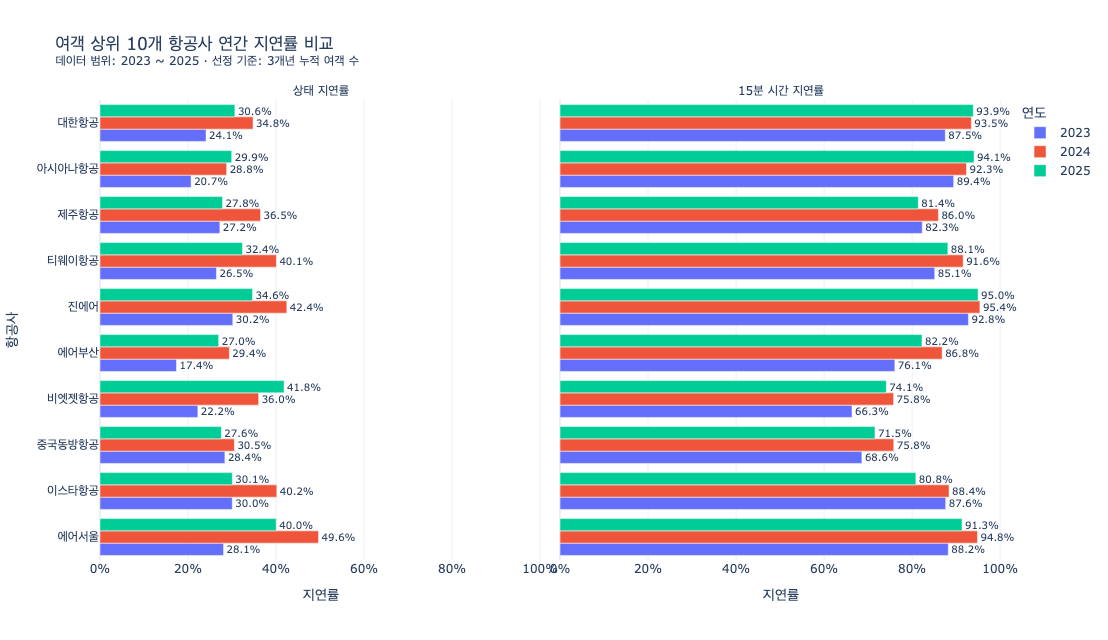

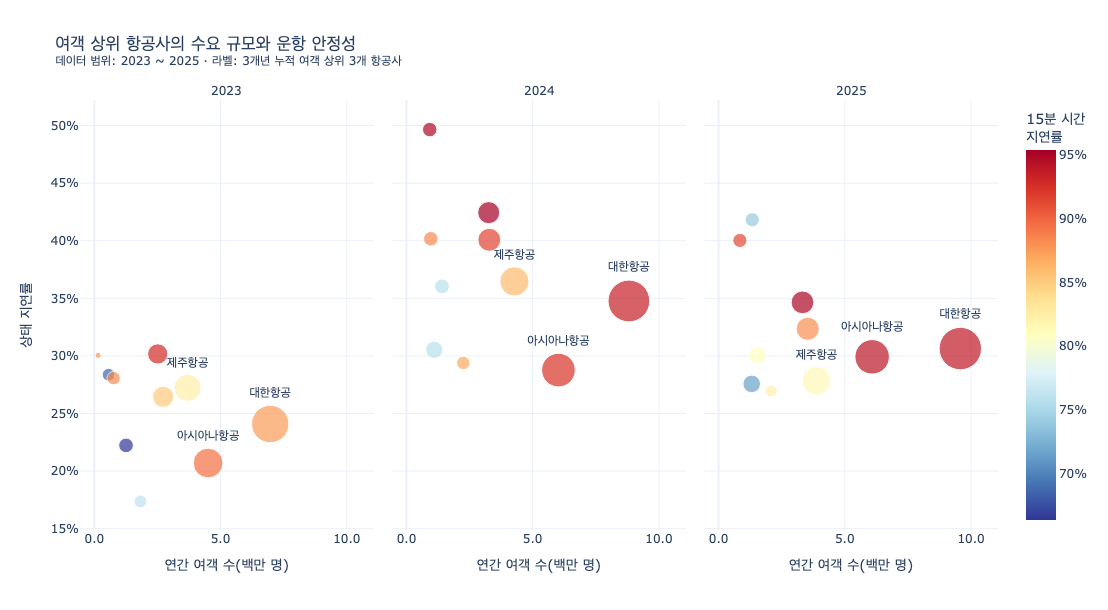

In [44]:
# 차트: 3개년 누적 여객 상위 10개 항공사의 연도별 두 지연률을 비교한다.
airline_chart = airline_yearly_stability_df.copy()
airline_chart['연도'] = airline_chart['연도'].astype(str)
airline_order = (
    airline_chart[['3개년 누적 순위', '항공사 표준값']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['항공사 표준값']
    .tolist()
)
airline_status = airline_chart[
    ['항공사 표준값', '연도', '상태 지연률']
].rename(columns={'상태 지연률': '지연률'})
airline_status['지연 기준'] = '상태 지연률'
airline_time = airline_chart[
    ['항공사 표준값', '연도', '15분 시간 지연률']
].rename(columns={'15분 시간 지연률': '지연률'})
airline_time['지연 기준'] = '15분 시간 지연률'
airline_delay_long = pd.concat([airline_status, airline_time], ignore_index=True)
fig = px.bar(
    airline_delay_long,
    x='지연률',
    y='항공사 표준값',
    color='연도',
    text='지연률',
    facet_col='지연 기준',
    barmode='group',
    orientation='h',
    title=chart_title(
        '여객 상위 10개 항공사 연간 지연률 비교',
        airline_chart['연도'],
        '선정 기준: 3개년 누적 여객 수',
    ),
    labels={'항공사 표준값': '항공사'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.0%')
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_yaxes(categoryorder='array', categoryarray=airline_order[::-1])
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.update_layout(height=640, legend_title_text='연도')
fig.show(config={'displaylogo': False})

# 차트: 항공사별 여객 규모와 운항 안정성을 같은 좌표에서 비교한다.
airline_demand_stability_chart = airline_chart.copy()
airline_demand_stability_chart['연간 여객 수(백만 명)'] = (
    airline_demand_stability_chart['여객 수'] / 1_000_000
)
airline_demand_stability_chart['표시 항공사'] = (
    airline_demand_stability_chart['항공사 표준값']
    .where(airline_demand_stability_chart['3개년 누적 순위'] <= 3, '')
)
fig = px.scatter(
    airline_demand_stability_chart,
    x='연간 여객 수(백만 명)',
    y='상태 지연률',
    size='분석 대상 운항 로그 수',
    color='15분 시간 지연률',
    text='표시 항공사',
    facet_col='연도',
    hover_name='항공사 표준값',
    hover_data={
        '여객 수': ':,',
        '3개년 누적 여객 수': ':,',
        '여객 전년 대비 증감률': ':.2%',
        '상태 지연률': ':.2%',
        '15분 시간 지연률': ':.2%',
        '취소율': ':.2%',
        '회항률': ':.2%',
        '표시 항공사': False,
    },
    category_orders={'연도': ['2023', '2024', '2025']},
    color_continuous_scale='RdYlBu_r',
    size_max=30,
    title=chart_title(
        '여객 상위 항공사의 수요 규모와 운항 안정성',
        airline_demand_stability_chart['연도'],
        note='라벨: 3개년 누적 여객 상위 3개 항공사',
    ),
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.1f')
fig.update_yaxes(tickformat='.0%')
fig.update_traces(textposition='top center')
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.update_layout(
    height=610,
    coloraxis_colorbar={'title': {'text': '15분 시간<br>지연률'}, 'tickformat': '.0%'},
)
fig.show(config={'displaylogo': False})


### 항공사 관찰

2023~2025년 3개년 누적 여객 상위 3개 항공사는 대한항공 2,536만 명, 아시아나항공 1,661만 명, 제주항공 1,185만 명이다. 이 가운데 누적 여객 1위인 대한항공의 연간 여객은 2024년 881만 명에서 2025년 958만 명으로 증가했다. 같은 기간 상태 지연률은 34.77%에서 30.64%로 낮아졌지만 15분 시간 지연률은 93.45%에서 93.88%로 높아져, 수요가 증가한 한 항공사 안에서도 지연 기준에 따라 변화 방향이 다르게 관찰됐다.

연간 지연률은 월별 비율 평균이 아니라 연간 분자 합계를 연간 분모 합계로 나눈 값이다. 또한 전국 항공사 수요와 인천·김포 출발 로그의 모집단 차이가 있으므로, 이 결과는 항공사의 전국 운항 품질 평가가 아니라 두 공항에서 관찰된 국제선 운항 특성으로 해석한다.

**비즈니스 인사이트.** 대한항공은 2024년 대비 2025년 여객이 881만 명에서 958만 명으로 증가했지만 상태 지연률은 34.77%에서 30.64%로 낮아지고 15분 시간 지연률은 93.45%에서 93.88%로 높아졌다. 전국 누적 여객 순위는 항공사 규모의 참고값이며, 특정 목적지에서의 운항 편의성과 안정성을 대신하지 않는다.

In [45]:
demand_stability_airport_df = query('demand_stability_airport_metrics')
display(demand_stability_airport_df.head(5))


,연월,출발공항 표준값,여객 수,여객 비중,여객 전년 동월 대비 증감률,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,상태 지연률,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,15분 시간 지연률,취소 편 수,취소율,회항 편 수,회항률,평균 실제-계획 출발시간 차이(분),15분 시간 지연편 평균 지연시간(분),15분 시간 지연편 중앙 지연시간(분)
0,202301,김포,78010.0,0.0325,NaN,464,463.0,37.0,0.0799,461.0,162.0,0.3514,0.0,0.0000,0.0,0.0000,16.15,29.43,21.0
1,202301,인천,1988706.0,0.8274,NaN,9073,8891.0,3029.0,0.3407,8875.0,7622.0,0.8588,13.0,0.0014,5.0,0.0006,35.83,40.16,31.0
2,202302,김포,85298.0,0.0386,NaN,438,437.0,15.0,0.0343,431.0,142.0,0.3295,0.0,0.0000,0.0,0.0000,13.71,22.54,19.0
3,202302,인천,1793507.0,0.8106,NaN,8426,8235.0,1781.0,0.2163,8223.0,6432.0,0.7822,4.0,0.0005,0.0,0.0000,26.96,31.97,25.5
4,202303,김포,105732.0,0.0469,NaN,589,589.0,15.0,0.0255,587.0,198.0,0.3373,0.0,0.0000,0.0,0.0000,13.00,20.47,18.0


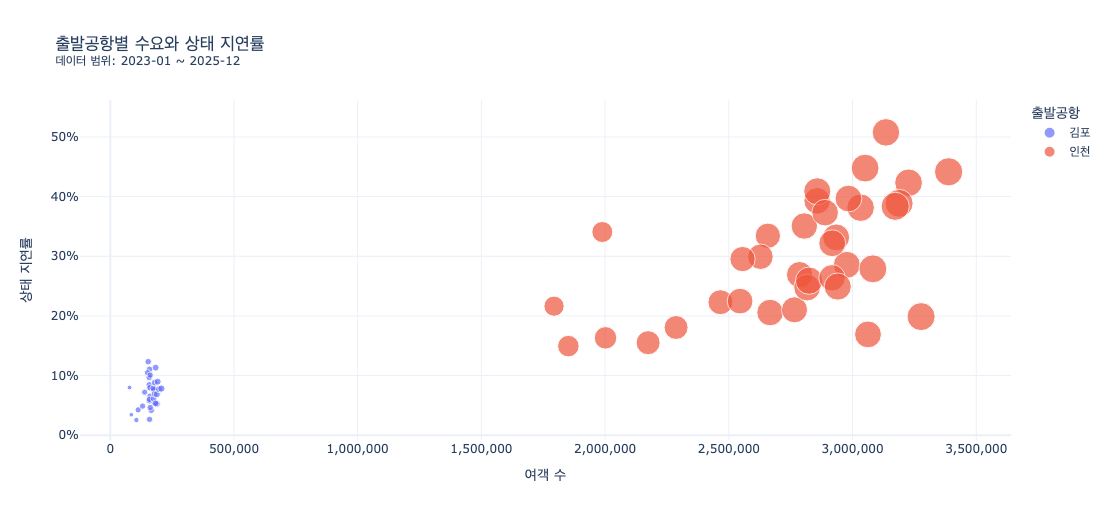

In [46]:
# 차트: 공항별 월간 여객 수요와 상태 지연률의 관계를 비교한다.
airport_stability_chart = demand_stability_airport_df.copy()
fig = px.scatter(
    airport_stability_chart,
    x='여객 수',
    y='상태 지연률',
    color='출발공항 표준값',
    size='분석 대상 운항 로그 수',
    hover_name='연월',
    hover_data={'15분 시간 지연률': ':.2%', '여객 비중': ':.2%'},
    title=chart_title('출발공항별 수요와 상태 지연률', airport_stability_chart['연월']),
    labels={'출발공항 표준값': '출발공항'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat=',')
fig.update_yaxes(tickformat='.0%')
fig.update_layout(height=520, legend_title_text='출발공항')
fig.show(config={'displaylogo': False})


In [47]:
yearly_demand_stability_destination_df = query('yearly_demand_stability_destination_metrics')
display(yearly_demand_stability_destination_df.head(5))


,연도,3개년 누적 순위,3개년 누적 여객 수,목적지 대표 표준값,여객 수,운항편 수,여객 비중,여객 전년 대비 증감률,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,상태 지연률,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,15분 시간 지연률,취소 편 수,취소율,회항 편 수,회항률,15분 시간 지연편 평균 지연시간(분)
0,2023,1,10074906.0,간사이,2958140.0,15827.0,0.0866,NaN,11530.0,11436.0,2022.0,0.1768,11427.0,8975.0,0.7854,16.0,0.0014,2.0,0.0002,31.04
1,2024,1,10074906.0,간사이,3499844.0,18606.0,0.0788,0.1831,13285.0,13110.0,3956.0,0.3018,12950.0,10852.0,0.8380,21.0,0.0016,1.0,0.0001,38.63
2,2025,1,10074906.0,간사이,3616922.0,20287.0,0.0766,0.0335,14589.0,14576.0,3521.0,0.2416,14558.0,11633.0,0.7991,6.0,0.0004,1.0,0.0001,34.84
3,2023,2,8028573.0,도쿄나리타,2193165.0,12690.0,0.0642,NaN,9078.0,9006.0,1792.0,0.1990,9002.0,7775.0,0.8637,3.0,0.0003,0.0,0.0000,31.07
4,2024,2,8028573.0,도쿄나리타,2929036.0,16181.0,0.0660,0.3355,11626.0,11487.0,4256.0,0.3705,11367.0,10552.0,0.9283,21.0,0.0018,1.0,0.0001,40.33


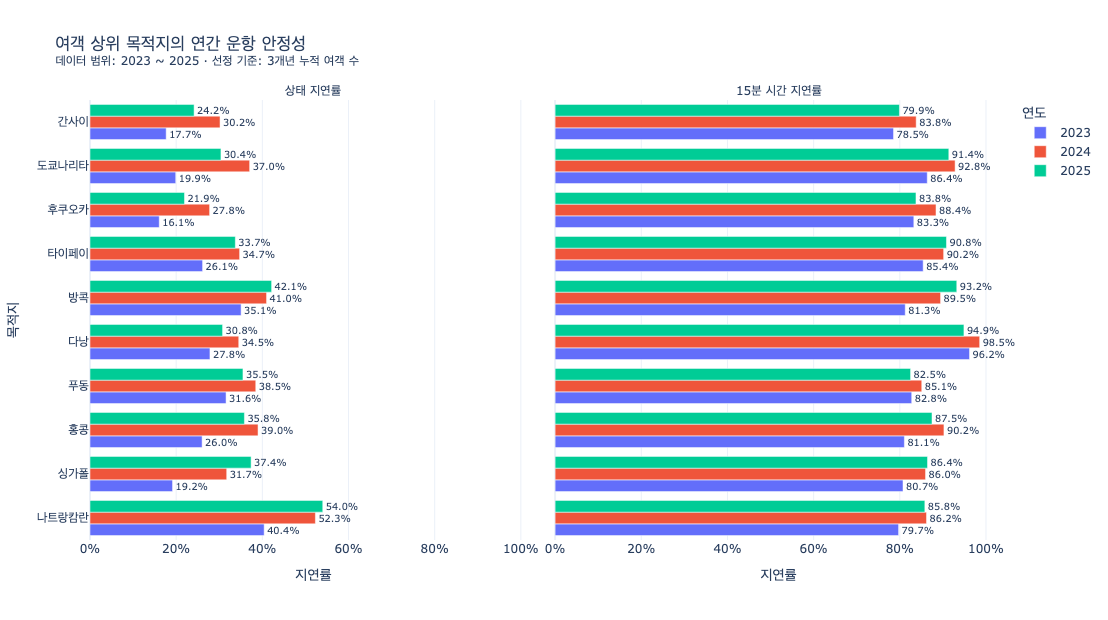

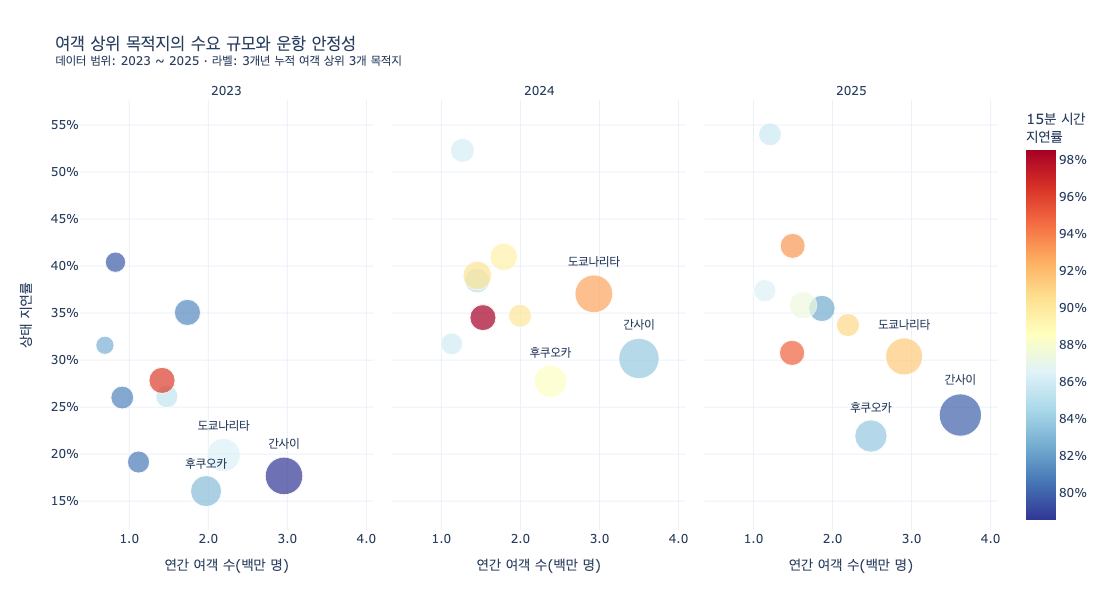

In [48]:
# 차트: 3개년 누적 여객 상위 10개 목적지의 연도별 수요와 두 지연률을 비교한다.
destination_stability_chart = yearly_demand_stability_destination_df.copy()
destination_stability_chart['연도'] = destination_stability_chart['연도'].astype(str)
destination_stability_order = (
    destination_stability_chart[['3개년 누적 순위', '목적지 대표 표준값']]
    .drop_duplicates()
    .sort_values('3개년 누적 순위')['목적지 대표 표준값']
    .tolist()
)
destination_stability_status = destination_stability_chart[
    ['목적지 대표 표준값', '연도', '상태 지연률']
].rename(columns={'상태 지연률': '지연률'})
destination_stability_status['지연 기준'] = '상태 지연률'
destination_stability_time = destination_stability_chart[
    ['목적지 대표 표준값', '연도', '15분 시간 지연률']
].rename(columns={'15분 시간 지연률': '지연률'})
destination_stability_time['지연 기준'] = '15분 시간 지연률'
destination_stability_long = pd.concat(
    [destination_stability_status, destination_stability_time], ignore_index=True
)
fig = px.bar(
    destination_stability_long,
    x='지연률',
    y='목적지 대표 표준값',
    color='연도',
    text='지연률',
    facet_col='지연 기준',
    barmode='group',
    orientation='h',
    title=chart_title(
        '여객 상위 목적지의 연간 운항 안정성',
        destination_stability_chart['연도'],
        '선정 기준: 3개년 누적 여객 수',
    ),
    labels={'목적지 대표 표준값': '목적지'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.0%')
fig.update_traces(texttemplate='%{text:.1%}', textposition='outside', cliponaxis=False)
fig.update_yaxes(
    categoryorder='array', categoryarray=destination_stability_order[::-1]
)
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.update_layout(height=620, legend_title_text='연도')
fig.show(config={'displaylogo': False})

# 차트: 목적지별 여객 규모와 운항 안정성을 같은 좌표에서 비교한다.
destination_demand_stability_chart = destination_stability_chart.copy()
destination_demand_stability_chart['연간 여객 수(백만 명)'] = (
    destination_demand_stability_chart['여객 수'] / 1_000_000
)
destination_demand_stability_chart['표시 목적지'] = (
    destination_demand_stability_chart['목적지 대표 표준값']
    .where(destination_demand_stability_chart['3개년 누적 순위'] <= 3, '')
)
fig = px.scatter(
    destination_demand_stability_chart,
    x='연간 여객 수(백만 명)',
    y='상태 지연률',
    size='분석 대상 운항 로그 수',
    color='15분 시간 지연률',
    text='표시 목적지',
    facet_col='연도',
    hover_name='목적지 대표 표준값',
    hover_data={
        '여객 수': ':,',
        '3개년 누적 여객 수': ':,',
        '여객 전년 대비 증감률': ':.2%',
        '상태 지연률': ':.2%',
        '15분 시간 지연률': ':.2%',
        '취소율': ':.2%',
        '회항률': ':.2%',
        '표시 목적지': False,
    },
    category_orders={'연도': ['2023', '2024', '2025']},
    color_continuous_scale='RdYlBu_r',
    size_max=30,
    title=chart_title(
        '여객 상위 목적지의 수요 규모와 운항 안정성',
        destination_demand_stability_chart['연도'],
        note='라벨: 3개년 누적 여객 상위 3개 목적지',
    ),
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.1f')
fig.update_yaxes(tickformat='.0%')
fig.update_traces(textposition='top center')
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.update_layout(
    height=610,
    coloraxis_colorbar={'title': {'text': '15분 시간<br>지연률'}, 'tickformat': '.0%'},
)
fig.show(config={'displaylogo': False})


> ### 가설 4 관찰 결과
>
> **가설 — 여객이 많거나 증가한 목적지·항공사라고 해서 지연률도 반드시 높거나 증가하지는 않을 것이다.**
>
> **판정 — 관찰 범위에서 가설의 예상 방향과 일치했다.** 목적지와 항공사 사례에서 수요와 운항 안정성 지표가 항상 같은 방향으로 움직이지 않았으며, 두 지표 사이에 관계가 없다고 판정한 것은 아니다.
>
> **관찰 결과 — 3개년 누적 여객 1위 목적지인 간사이의 여객은 증가했지만 상태 지연률은 2024년 30.18%에서 2025년 24.16%로 낮아져, 관찰 범위에서 수요와 운항 안정성이 항상 같은 방향으로 움직이지는 않았다.**
>
> - **확인된 근거 — 목적지:** 간사이의 연간 여객은 2023년 296만 명에서 2025년 362만 명으로 증가했다. 특히 2024년 대비 2025년 여객은 증가했지만 상태 지연률은 낮아졌다.
> - **확인된 근거 — 항공사:** 대한항공의 연간 여객은 2024년 881만 명에서 2025년 958만 명으로 증가한 반면, 상태 지연률은 34.77%에서 30.64%로 낮아지고 15분 시간 지연률은 93.45%에서 93.88%로 높아졌다. 같은 수요 증가에서도 지연 기준에 따라 변화 방향이 달랐다.
> - **가능성 해석:** 수요와 지연률의 변화 방향이 일치하지 않은 것은 기상·공항 혼잡·운항 시간대·항공기 연결·스케줄 여유 등 수요 외 요인이 함께 작용했을 가능성을 보여준다. 다만 현재 자료에는 이러한 요인이 포함되지 않아 특정 원인의 영향으로 구분할 수 없다.
> - **비즈니스 인사이트:** 간사이는 2024년 대비 2025년 여객이 증가했지만 상태 지연률은 30.18%에서 24.16%로 낮아졌고, 대한항공도 여객 증가와 함께 두 지연률의 변화 방향이 달랐다. 목적지 인기는 탐색 정보로, 항공사 운항 지표는 선택지 비교 정보로 구분하며 전국 여객 규모를 특정 목적지의 항공사 품질로 해석하지 않는다.
> - **해석상 한계:** 전체 목적지의 상관계수를 검정한 결과가 아니므로 수요와 지연률의 관계가 없다고 단정하지 않는다. 수요는 전국 출발 집계이고 안정성은 인천·김포 출발 로그이므로 두 값을 인과적으로 연결하거나 그대로 합산하지 않는다. 05에서 추천 점수를 만들 때도 목적지 수요와 항공사 운항 지표의 역할을 구분하고 가중치와 원값을 공개해야 한다.

### 5.1. 누적 순위 밖의 최근 성장 후보는 얼마나 되는가

**후속 분석 질문.** 3개년 누적 상위만 사용하면 2024년 대비 2025년 여객 증가 수 상위 목적지를 얼마나 놓치는가?

**질문 수립 근거 — §1·본 섹션 가설 4 결과.** 누적 순위는 지속적으로 규모가 큰 시장을 보여주지만 최근 변화를 늦게 반영할 수 있다. 수요와 운항 안정성을 함께 비교할 대상도 기존 핵심 시장에만 한정하지 않도록 후보 범위를 확대한다.

**차트 용어 정의.**

- `누적`(`누적 상위`): 2023~2025년 3개년 누적 여객 수 상위 10개 목적지
- `최신`(`최신 연도 수요 상위`): 2025년 연간 여객 수 상위 10개 목적지
- `성장`(`최근 성장 상위`): 2024년 대비 2025년 여객 증가 수 상위 10개 목적지
- `누적·최신·성장`처럼 기준이 함께 표시되면 해당 목적지가 여러 선정 기준에 동시에 포함됐다는 의미다.

**확인 방법.** 3개년 누적 여객 상위 10개·2025년 여객 수 상위 10개·2024년 대비 2025년 여객 증가 수 상위 10개의 합집합을 만들고, 누적 상위 밖에서 추가되는 목적지와 선정 이유를 확인한다.

In [49]:
# 누적·최신 수요·최근 성장 상위 목적지의 연도별 수요와 운항 안정성을 확인한다.
destination_trend_stability_df = query('destination_trend_stability_metrics')
display(destination_trend_stability_df.head(10))


,연도,목적지 대표 표준값,선정 사유,3개년 누적 순위,최신 연도 수요 순위,최근 여객 증가 순위,3개년 누적 여객 수,최신 연도 여객 증가 수,여객 수,운항편 수,전년 여객 수,여객 전년 대비 증감률,분석 대상 운항 로그 수,상태 지연률 분모 편 수,상태 지연 편 수,상태 지연률,15분 시간 지연률 분모 편 수,15분 이상 시간 지연 편 수,15분 시간 지연률,취소 편 수,취소율,회항 편 수,회항률,15분 시간 지연편 평균 지연시간(분)
0,2023,간사이,누적 상위 + 최신 연도 수요 상위 + 최근 성장 상위,1,1,9.0,10074906.0,117078.0,2958140.0,15827.0,NaN,NaN,11530.0,11436.0,2022.0,0.1768,11427.0,8975.0,0.7854,16.0,0.0014,2.0,0.0002,31.04
1,2024,간사이,누적 상위 + 최신 연도 수요 상위 + 최근 성장 상위,1,1,9.0,10074906.0,117078.0,3499844.0,18606.0,2958140.0,0.1831,13285.0,13110.0,3956.0,0.3018,12950.0,10852.0,0.8380,21.0,0.0016,1.0,0.0001,38.63
2,2025,간사이,누적 상위 + 최신 연도 수요 상위 + 최근 성장 상위,1,1,9.0,10074906.0,117078.0,3616922.0,20287.0,3499844.0,0.0335,14589.0,14576.0,3521.0,0.2416,14558.0,11633.0,0.7991,6.0,0.0004,1.0,0.0001,34.84
3,2023,도쿄나리타,누적 상위 + 최신 연도 수요 상위,2,2,NaN,8028573.0,NaN,2193165.0,12690.0,NaN,NaN,9078.0,9006.0,1792.0,0.1990,9002.0,7775.0,0.8637,3.0,0.0003,0.0,0.0000,31.07
4,2024,도쿄나리타,누적 상위 + 최신 연도 수요 상위,2,2,NaN,8028573.0,NaN,2929036.0,16181.0,2193165.0,0.3355,11626.0,11487.0,4256.0,0.3705,11367.0,10552.0,0.9283,21.0,0.0018,1.0,0.0001,40.33
5,2025,도쿄나리타,누적 상위 + 최신 연도 수요 상위,2,2,NaN,8028573.0,NaN,2906372.0,16352.0,2929036.0,-0.0077,11207.0,11193.0,3402.0,0.3039,11178.0,10213.0,0.9137,6.0,0.0005,2.0,0.0002,36.71
6,2023,후쿠오카,누적 상위 + 최신 연도 수요 상위,3,3,12.0,6836989.0,105766.0,1971427.0,10950.0,NaN,NaN,7863.0,7816.0,1256.0,0.1607,7811.0,6503.0,0.8325,2.0,0.0003,0.0,0.0000,29.11
7,2024,후쿠오카,누적 상위 + 최신 연도 수요 상위,3,3,12.0,6836989.0,105766.0,2379898.0,12472.0,1971427.0,0.2072,8634.0,8505.0,2361.0,0.2776,8424.0,7447.0,0.8840,30.0,0.0035,4.0,0.0005,36.47
8,2025,후쿠오카,누적 상위 + 최신 연도 수요 상위,3,3,12.0,6836989.0,105766.0,2485664.0,12785.0,2379898.0,0.0444,8508.0,8506.0,1865.0,0.2193,8492.0,7112.0,0.8375,0.0,0.0000,0.0,0.0000,32.68
9,2023,타이페이,누적 상위 + 최신 연도 수요 상위 + 최근 성장 상위,4,4,2.0,5664867.0,199634.0,1474859.0,7269.0,NaN,NaN,4015.0,3995.0,1044.0,0.2613,3993.0,3411.0,0.8542,4.0,0.0010,0.0,0.0000,34.49


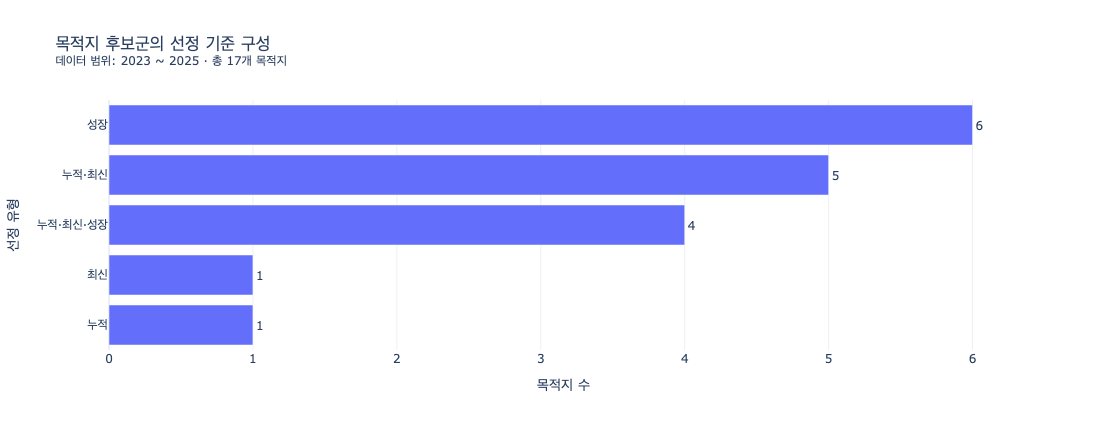

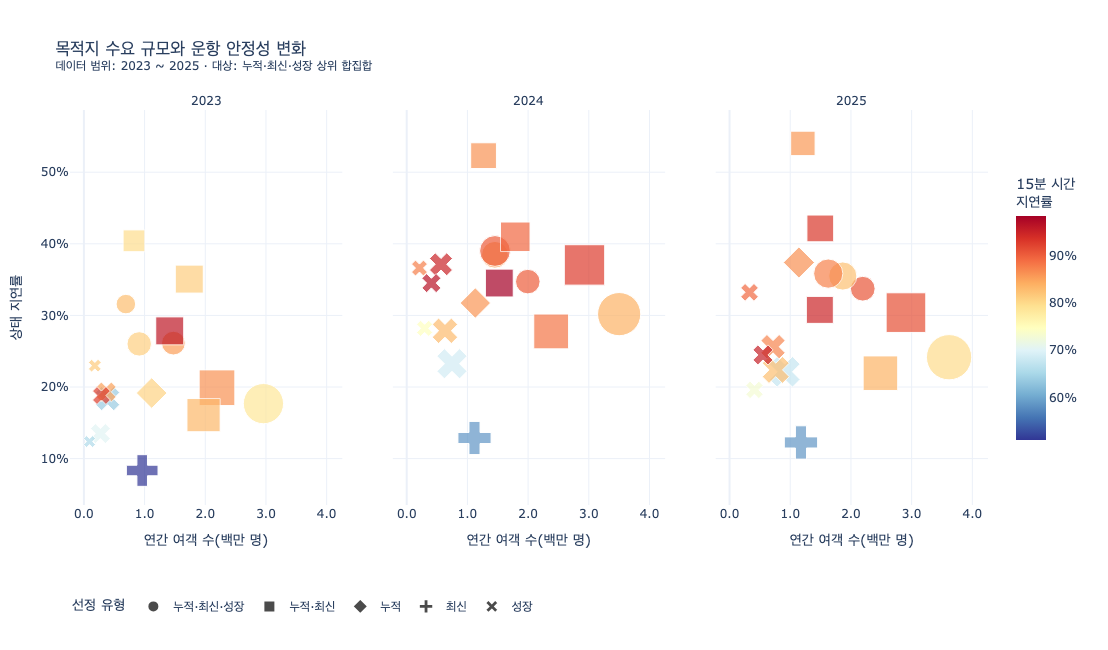

In [50]:
# 차트: 핵심·최신·성장 목적지의 연도별 수요 규모와 운항 안정성을 함께 비교한다.
destination_trend_chart = destination_trend_stability_df.copy()
destination_trend_chart['연도'] = destination_trend_chart['연도'].astype(str)
destination_trend_chart['연간 여객 수(백만 명)'] = (
    destination_trend_chart['여객 수'] / 1_000_000
)
destination_trend_chart['선정 유형'] = (
    destination_trend_chart['선정 사유']
    .str.replace('누적 상위', '누적', regex=False)
    .str.replace('최신 연도 수요 상위', '최신', regex=False)
    .str.replace('최근 성장 상위', '성장', regex=False)
    .str.replace(' + ', '·', regex=False)
)

# 차트: 후보군 17개가 어떤 선정 기준 조합으로 구성되는지 건수로 확인한다.
candidate_selection_summary = (
    destination_trend_chart[['목적지 대표 표준값', '선정 유형']]
    .drop_duplicates()
    .groupby('선정 유형', as_index=False)
    .agg(목적지_수=('목적지 대표 표준값', 'nunique'))
    .sort_values('목적지_수')
)
fig = px.bar(
    candidate_selection_summary,
    x='목적지_수',
    y='선정 유형',
    orientation='h',
    text='목적지_수',
    title=chart_title(
        '목적지 후보군의 선정 기준 구성',
        destination_trend_chart['연도'],
        note=f"총 {destination_trend_chart['목적지 대표 표준값'].nunique()}개 목적지",
    ),
    labels={'목적지_수': '목적지 수'},
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(dtick=1)
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(height=430, showlegend=False, margin={'r': 90})
fig.show(config={'displaylogo': False})

fig = px.scatter(
    destination_trend_chart,
    x='연간 여객 수(백만 명)',
    y='상태 지연률',
    size='분석 대상 운항 로그 수',
    color='15분 시간 지연률',
    symbol='선정 유형',
    facet_col='연도',
    facet_col_spacing=0.055,
    hover_name='목적지 대표 표준값',
    hover_data={
        '여객 수': ':,',
        '선정 사유': True,
        '3개년 누적 순위': ':.0f',
        '최신 연도 수요 순위': ':.0f',
        '최근 여객 증가 순위': ':.0f',
        '최신 연도 여객 증가 수': ':,',
        '여객 전년 대비 증감률': ':.2%',
        '취소율': ':.2%',
        '회항률': ':.2%',
    },
    category_orders={'연도': ['2023', '2024', '2025']},
    color_continuous_scale='RdYlBu_r',
    symbol_sequence=['circle', 'square', 'diamond', 'cross', 'x'],
    size_max=32,
    title=chart_title(
        '목적지 수요 규모와 운항 안정성 변화',
        destination_trend_chart['연도'],
        '대상: 누적·최신·성장 상위 합집합',
    ),
    template=PLOTLY_TEMPLATE,
)
fig.update_xaxes(tickformat='.1f', tickangle=0, nticks=5)
fig.update_yaxes(tickformat='.0%')
fig.for_each_annotation(lambda annotation: annotation.update(text=annotation.text.split('=')[-1]))
fig.update_layout(
    height=650,
    margin={'l': 70, 'r': 120, 't': 110, 'b': 145},
    legend={
        'orientation': 'h',
        'yanchor': 'top',
        'y': -0.22,
        'xanchor': 'left',
        'x': 0,
        'title': {'text': '선정 유형'},
    },
    coloraxis_colorbar={
        'title': {'text': '15분 시간<br>지연률'},
        'tickformat': '.0%',
        'x': 1.02,
        'len': 0.72,
    },
)
fig.show(config={'displaylogo': False})


> ### 후속 분석 질문 관찰 결과
>
> **핵심 결과 — 누적 상위 밖에서 2024년 대비 2025년 여객 증가 수 상위 10개 기준으로 6개, 2025년 수요 상위 10개 기준으로 1개 목적지가 추가됐다.**
>
> - 세 기준의 합집합에는 17개 목적지가 포함됐다. 나고야·북경·센젠·오끼나와·청도·카오슝은 2024년 대비 2025년 여객 증가 수 기준으로, 도쿄 하네다는 2025년 수요 기준으로 추가됐다.
> - 누적 순위는 기존 핵심 시장을 확인하는 기준으로, 최근 성장 순위는 새로운 탐색 후보를 찾는 참고 기준으로 활용할 수 있다. 추천 후보군도 `기존 핵심 목적지`와 `최근 성장 후보`를 구분해야 한다.
> - **비즈니스 인사이트:** 누적 상위 10개만 사용하면 성장 기준 6개와 최신 수요 기준 1개를 놓쳐 후보 범위가 합집합 17개로 달라진다. 추가 후보에는 선정 이유와 실제 시장 규모를 함께 표시하되, 17개를 같은 우선순위로 추천하지 않는다.
> - 합집합은 후보를 놓치지 않기 위한 탐색 범위이며, 추가된 목적지의 사업 우선순위나 예상 성과를 확정한 결과는 아니다.


## 6. 결론

### 가설 및 보조 분석 질문 관찰 결과

> **한 줄 결론 — 국제선 수요 상위 시장의 구성은 변하고 있었고, 사용자의 목적지·항공사 선택을 지원하려면 누적 인기·최근 성장·여행 시점·운항 안정성을 서로 다른 정보로 함께 제시할 필요가 나타났다.**
>
> | 구분 | 관찰 결과 | 의사결정 연결 |
> |---|---|---|
> | 가설 1 · 핵심 시장 집중 | **판정: 관찰 범위에서 예상 방향과 일치.** 상위 시장의 개별 비중이 크게 관찰됐고, 출발공항 중 3개년 누적 여객 1위인 인천의 연간 비중은 2023년 81.29%에서 2025년 77.49%로 낮아졌다. | 누적 인기와 최근 비중 변화를 분리해 목적지 탐색 정보를 구성한다. |
> | 가설 2 · 목적지별 계절성 | **판정: 관찰 범위에서 예상 방향과 일치.** 주요 목적지의 월별 상대 수요에 차이가 나타났고, 3개년 누적 여객 1위 목적지이면서 12개월 모두 월별 여객 상위 5위에 포함된 간사이는 12월의 3개년 평균 계절 지수가 1.1742였다. | 여행 예정 월에 맞는 목적지 맥락 정보로 활용하되 항공사 품질과 구분한다. |
> | 가설 3 · 수요·운항 증가의 비대칭 | **판정: 관찰 범위에서 예상 방향과 일치.** 2024년 대비 2025년 여객 증가 수 1위인 푸동에서 여객 증가율 28.41%와 운항 증가율 15.05%의 차이가 관찰됐다. | 증가 인원·증가율·기존 규모를 함께 표시해 최근 성장 후보를 설명한다. |
> | 보조 분석 질문 · 대륙별 방문 도시 | 아시아의 인기·성장 규모가 크지만, 유럽의 프라하·미주의 밴쿠버·대양주의 괌처럼 대륙 안에서 별도 후보가 확인됐다. | 대륙을 먼저 선택한 뒤 인기·성장 도시를 나란히 제시한다. |
> | 보조 분석 질문 · 운항 지표 | 최신 관측 월인 2025년 12월 상태 지연률은 19.13%, 15분 시간 지연률은 79.22%였다. | 두 지연률과 취소·회항, 계산 가능한 운항편 수를 분리해 제공하되 추천 순위 반영 여부는 목적지×항공사 단위의 변별력을 확인한 뒤 결정한다. |
> | 가설 4 · 수요와 운항 안정성 | **판정: 관찰 범위에서 예상 방향과 일치.** 간사이의 여객은 증가했지만 상태 지연률은 낮아졌고, 대한항공은 2024년 대비 2025년 여객 증가와 함께 상태 지연률이 34.77%에서 30.64%로 낮아지고 15분 시간 지연률은 93.45%에서 93.88%로 높아졌다. | 목적지 인기는 탐색 기준으로, 항공사 운항 지표는 선택지 비교 기준으로 분리한다. |
> | ↳ 후속 분석 질문 · 후보 범위 | 누적 상위 밖에서 2024년 대비 2025년 여객 증가 수 기준 6개, 2025년 수요 기준 1개 목적지가 추가됐다. | 핵심·성장 후보를 함께 제공하되 선정 이유와 실제 규모를 표시한다. |

### 핵심 발견

- **핵심 시장과 최근 성장 후보는 서로 다른 기준으로 식별된다.** 누적 순위는 규모가 큰 기존 시장을, 최근 증가 순위는 최근 여객 증가 폭이 큰 후보를 보여준다.
- **목적지별 월별 상대 수요에 차이가 나타났다.** 여행 예정 월에 맞는 목적지 탐색 정보로 활용할 수 있지만, 3개년 평균만으로 장기적인 반복 계절성을 확정하지 않는다.
- **일부 최근 성장 후보에서는 여객과 운항의 증가율 차이가 관찰됐다.** 여객 증가 수와 증가율, 운항 증가 폭을 함께 비교하되 여객 증가 수 1위인 푸동 사례를 전체 목적지에 일반화하지 않는다.
- **대륙별 드릴다운이 필요하다.** 전체 순위는 아시아 중심이지만, 대륙 안의 인기·성장 순위는 지역별 캠페인 후보를 구분하는 데 유용하다.
- **운항 지표는 하나의 지연률로 요약하지 않는다.** 상태 지연·15분 시간 지연·취소·회항은 서로 다른 정보를 제공한다.
- **관찰 범위에서 수요와 운항 안정성이 항상 같은 방향으로 움직이지는 않았다.** 간사이와 대한항공 모두 2024년 대비 2025년 여객은 증가했지만 상태 지연률은 낮아졌고, 대한항공의 15분 시간 지연률은 같은 기간 소폭 높아졌다. 전체 상관관계를 검정한 것은 아니므로 두 축의 원값과 변화 방향을 따로 비교한다.

### 분석 결과 기반 활용 제안

| 분석 근거 | 기존 산출값 | 활용 제안 | 적용 범위·한계 |
|---|---|---|---|
| 핵심 시장의 비중 변화와 누적 순위 밖 후보가 함께 관찰됐다. | 인천 비중은 2023년 81.29%에서 2025년 77.49%로 낮아졌고, 누적·최신·성장 기준의 목적지 합집합은 17개였다. 누적 상위 밖에서 성장 기준 6개와 최신 수요 기준 1개가 추가됐다. | 17개 후보를 누적·최신·성장 선정 사유와 함께 제공한다. | 후보 범위를 확장한 결과이며 17개를 같은 우선순위로 추천하지 않는다. |
| 목적지별 월별 상대 수요에 차이가 나타났다. | 간사이의 12월 계절지수는 1.1742였고, 방콕은 1월 1.2531·5월 0.8476이었다. | 여행 예정 월에 맞는 상대 수요 정보를 목적지 설명에 활용한다. | 현재 차트는 3개 연도 모두 관측된 목적지 중 월별 평균 수요 상위 5개를 보여준다. |
| 상태 지연률과 15분 시간 지연률의 결과가 크게 달랐다. | 2025년 12월 상태 지연률은 19.13%, 15분 시간 지연률은 79.22%로 60.09%p 차이가 나타났다. | 두 지연률·취소·회항과 계산 가능한 운항편 수를 분리해 제공한다. | 04는 월별 전체·2개 공항·누적 운항 로그 상위 10개 목적지를 비교했으며, 15분 지표의 목적지×항공사 순위 변별력은 확인하지 않았다. |
| 수요와 운항 안정성이 항상 같은 방향으로 움직이지 않았다. | 간사이의 상태 지연률은 2024년 30.18%에서 2025년 24.16%로 낮아졌고, 대한항공은 같은 기간 상태 지연률이 34.77%에서 30.64%로 낮아진 반면 15분 시간 지연률은 93.45%에서 93.88%로 높아졌다. | 전국 여객 규모를 항공사 추천 점수로 사용하지 않고 목적지 수요와 항공사 운항 지표의 역할을 구분한다. | 현재 결과는 누적 수요 상위 10개 항공사·목적지의 연간 비교이며 목적지×항공사 추천 순위는 산출하지 않았다. |

위 제안은 현재 관찰 데이터에서 도출한 활용 방향이며, 예약 전환이나 매출 효과를 확인한 결과는 아니다. 실제 적용 우선순위는 가격·좌석·예약·수익성 자료를 추가한 뒤 판단한다.

### 다음 작업 방향 · 05 연결

05에서는 위 활용 제안을 바탕으로 항공사 비교가 가능한 데이터 범위와 점수 구성을 먼저 확인한다.

- `국가·지역 → 목적지 공항 → 항공사` 순으로 탐색 단위를 구성한다.
- 목적지에는 누적 인기·최근 성장·여행 월별 상대 수요를 별도 정보로 제공한다.
- 목적지×항공사 단위의 운항편 수·15분 시간 지연률·취소·회항과 분모 편 수를 먼저 구성한다.
- 각 지표가 실제로 서로 다른 항공사 순위를 만드는지 확인하고, 변별력과 설명력이 확인된 기준만 추천 모드로 채택한다. 04 단계에서는 추천 모드의 개수를 확정하지 않는다.
- 운항편이 적은 항공사는 `표본 부족`으로 구분하고 원값·가중치·분모를 함께 공개한다.
- 클릭률·상세 조회율·이탈률·예약 전환율은 실제 서비스 적용 시 확인할 검증 지표로만 정의하며, 현재 프로젝트에서는 측정하지 않는다.

### 해석상 한계

- 수요는 전국 국제선 출발 집계이지만 운항 안정성은 인천·김포 출발 국제선 여객편 로그다. 결합 결과의 여객 수와 운항 로그 수는 동일 모집단의 분자·분모가 아니다.
- 2023년 5월 항공사별·노선별 원본 운항 집계에는 1편 차이가 남아 있다.
- 계절성과 성장성은 2023~2025년 관찰 결과이며 장기 구조나 인과관계를 확정하지 않는다.
- 가격·좌석 공급·예약·수익성·기상·공항 혼잡 자료가 없으므로 가성비, 수익성, 지연의 원인과 정책 효과를 단정할 수 없다.
- 현재 항공사 추천 근거는 인천·김포 출발 로그의 관찰 결과이며, 가격·서비스 품질·사용자 선호와 실제 예약 성과를 포함한 종합 추천은 아니다.
